In [16]:
# !pip install pandas
# !pip install matplotlib
# !pip install openpyxl
# !pip install scikit-learn
# !pip install seaborn
# !pip install statsmodels
# !pip install xgboost

In [17]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os
import re


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *
from statsmodels.tsa.stattools import acf

from hmmlearn.hmm import GaussianHMM

In [18]:
# Define the columns and the prefixes you want to use
freq_a = 'Frequency 6EF39700 (Hgr Kitatumba - Labo)'
freq_b = 'Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)'
volt_a = 'Voltage 6EF39700 (Hgr Kitatumba - Labo)'
volt_b = 'Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)'


# Define the columns and the prefixes you want to use
columns_to_compare = [
    (freq_a, 'freq_lab'),
    (freq_b, 'freq_clinique'),
    (volt_a, 'volt_lab'),
    (volt_b, 'volt_clinique')
]


# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [19]:
# Opening files
file_list = ['Voltage Time Series-data-2025-05-03 11_39_02.csv',  
             'Voltage Time Series-data-2025-05-03 11_39_29.csv', 
             'Voltage Time Series-data-2025-05-03 11_39_43.csv',
             'Voltage Time Series-data-2025-05-03 11_39_57.csv']

file_path = '../../data/5. Combination 5/training/kitatumba/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON
0,1/1/23 0:00,50.0,50.0,211.0,214.0,False
1,1/1/23 0:02,49.7,49.7,209.0,214.0,False
2,1/1/23 0:04,50.2,50.1,209.0,214.0,False
3,1/1/23 0:06,50.1,50.1,211.0,214.0,False
4,1/1/23 0:08,49.7,49.7,209.0,214.0,False
...,...,...,...,...,...,...
20155,1/28/23 23:50,50.0,50.0,216.0,223.0,False
20156,1/28/23 23:52,49.9,49.9,216.0,223.0,False
20157,1/28/23 23:54,49.9,49.9,216.0,223.0,False
20158,1/28/23 23:56,50.0,50.0,216.0,223.0,False


In [20]:
# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON
0,1/1/23 0:00,50.0,50.0,211.0,214.0,False
1,1/1/23 0:02,49.7,49.7,209.0,214.0,False
2,1/1/23 0:04,50.2,50.1,209.0,214.0,False
3,1/1/23 0:06,50.1,50.1,211.0,214.0,False
4,1/1/23 0:08,49.7,49.7,209.0,214.0,False
...,...,...,...,...,...,...
20155,1/9/23 9:50,50.3,50.2,190.0,198.0,False
20156,1/9/23 9:52,49.9,49.9,188.0,195.0,False
20157,1/9/23 9:54,49.9,49.9,190.0,197.0,False
20158,1/9/23 9:56,50.2,50.2,176.0,185.0,False


In [21]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")
data['Time'].dtype

dtype('<M8[ns]')

In [22]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,time_diff
0,2023-01-01,50.0,50.0,211.0,214.0,False,NaT


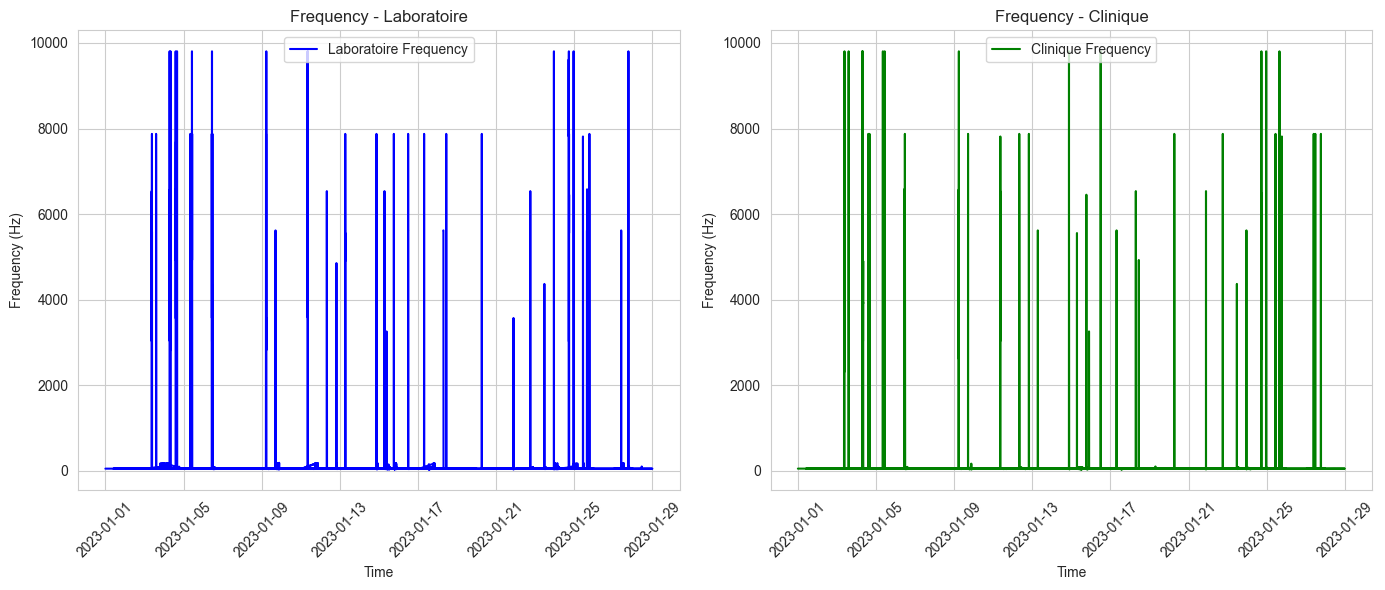

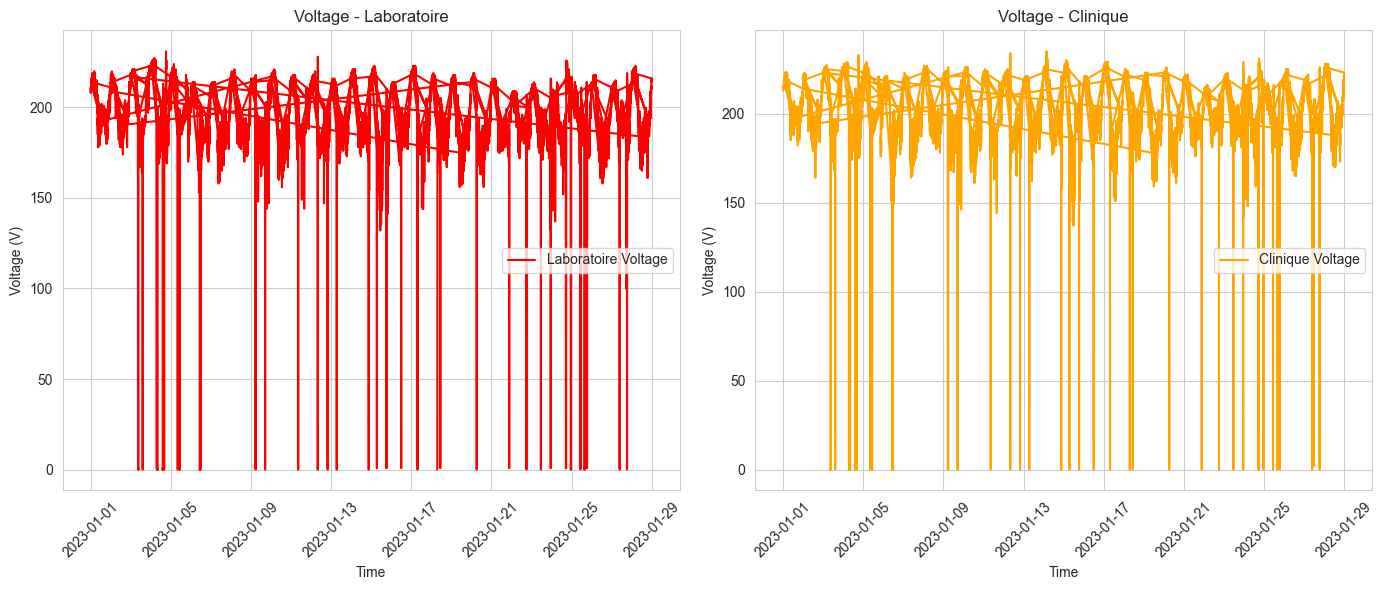

In [23]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[freq_a], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[freq_b], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data[volt_a], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data[volt_b], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# List of columns to calculate statistics
columns_of_interest = [
    freq_a,
    freq_b,
    volt_a,
    volt_b
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

                 Frequency 6EF39700 (Hgr Kitatumba - Labo)  \
Mean                                            120.292362   
Median                                           49.900000   
1st Percentile                                   41.900000   
99th Percentile                                3584.000000   
Null Count (%)                                    0.000495   

                 Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)  \
Mean                                                  115.246431   
Median                                                 49.900000   
1st Percentile                                         41.400000   
99th Percentile                                      3639.860000   
Null Count (%)                                          0.000043   

                 Voltage 6EF39700 (Hgr Kitatumba - Labo)  \
Mean                                          194.334059   
Median                                        194.000000   
1st Percentile                        

# 2. Training and Test Data Separation

In [25]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

Training data size: 12096
Test data size: 8064
Training Data Sample:


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON
0,2023-01-01 00:00:00,50.0,50.0,211.0,214.0,False
1,2023-01-01 00:02:00,49.7,49.7,209.0,214.0,False
2,2023-01-01 00:04:00,50.2,50.1,209.0,214.0,False
3,2023-01-01 00:06:00,50.1,50.1,211.0,214.0,False
4,2023-01-01 00:08:00,49.7,49.7,209.0,214.0,False
...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,61.1,45.2,206.0,212.0,True
12092,2023-01-24 05:04:00,90.0,45.4,205.0,212.0,True
12093,2023-01-24 05:06:00,45.7,45.7,205.0,211.0,True
12094,2023-01-24 05:08:00,46.1,46.2,208.0,214.0,True


Test Data Sample:


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON
12096,2023-01-24 05:12:00,45.7,45.9,205.0,212.0,True
12097,2023-01-24 05:14:00,45.0,45.0,204.0,211.0,True
12098,2023-01-24 05:16:00,45.1,45.2,205.0,211.0,True
12099,2023-01-24 05:18:00,90.6,45.0,206.0,213.0,True
12100,2023-01-24 05:20:00,45.8,45.6,209.0,215.0,True
...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.3,50.2,190.0,198.0,False
20156,2023-01-09 09:52:00,49.9,49.9,188.0,195.0,False
20157,2023-01-09 09:54:00,49.9,49.9,190.0,197.0,False
20158,2023-01-09 09:56:00,50.2,50.2,176.0,185.0,False


# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [26]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [27]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

'Train data for baseline:'

0        False
1        False
2        False
3        False
4        False
         ...  
12091    False
12092    False
12093    False
12094    False
12095    False
Name: prediction, Length: 12096, dtype: bool

'Test data for baseline:'

12096    False
12097    False
12098    False
12099    False
12100    False
         ...  
20155    False
20156    False
20157    False
20158    False
20159    False
Name: prediction, Length: 8064, dtype: bool

Assessing the model:

In [28]:
print("y_true unique values:", train_data_base['Generator_ON'].unique())
print("y_pred unique values:", train_data_base['prediction'].unique())
print("y_true dtype:", train_data_base['Generator_ON'].dtype)
print("y_pred dtype:", train_data_base['prediction'].dtype)

train_data_base[train_data_base['Generator_ON'].isna()]

y_true unique values: [False  True]
y_pred unique values: [False]
y_true dtype: bool
y_pred dtype: bool


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,prediction


In [29]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

Accuracy of model: 0.829943783068783
Confusion Matrix:
[[10039     0]
 [ 2057     0]]
Precision of model: 0.0
Recall of model: 0.0


In [30]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

Accuracy of model: 0.7410714285714286
Confusion Matrix:
[[5976    0]
 [2088    0]]
Precision of model: 0.0
Recall of model: 0.0


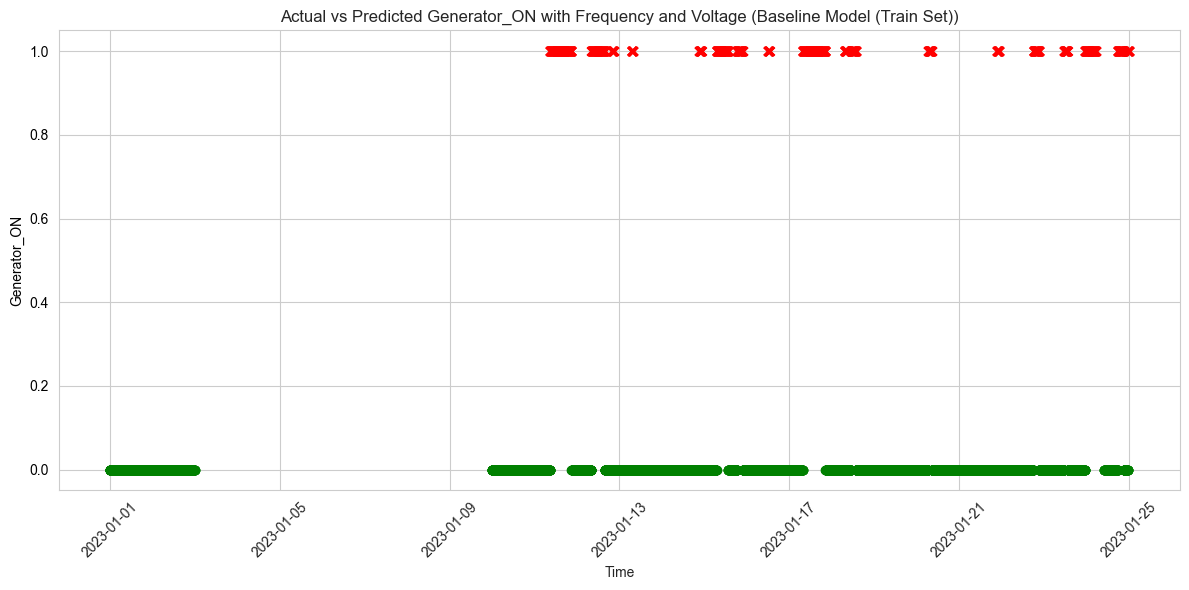

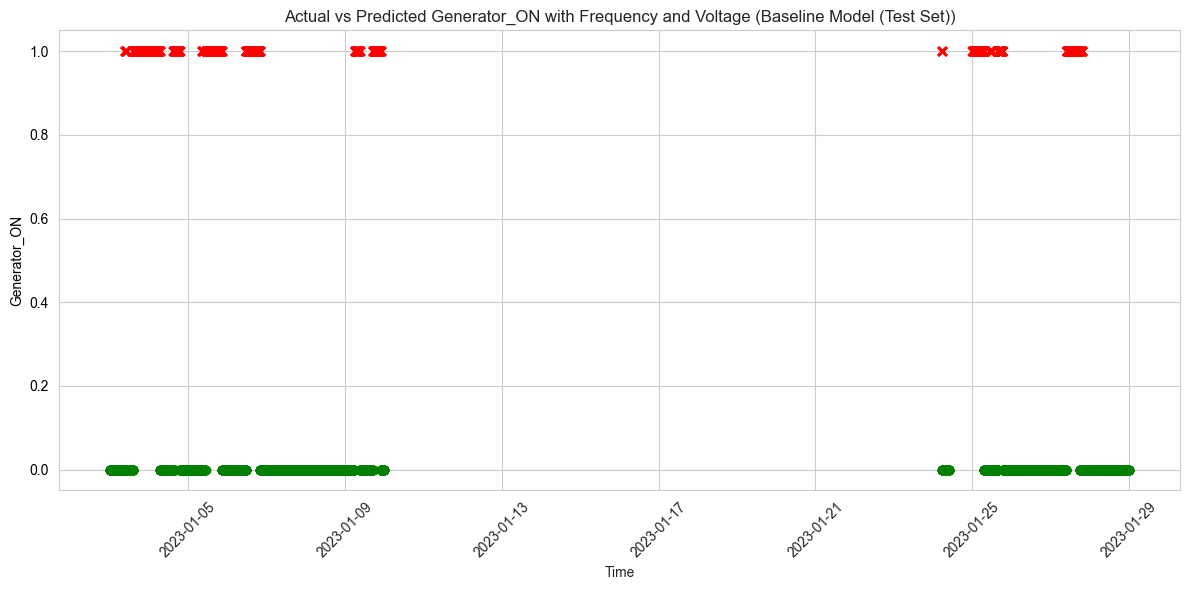

In [31]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", 
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

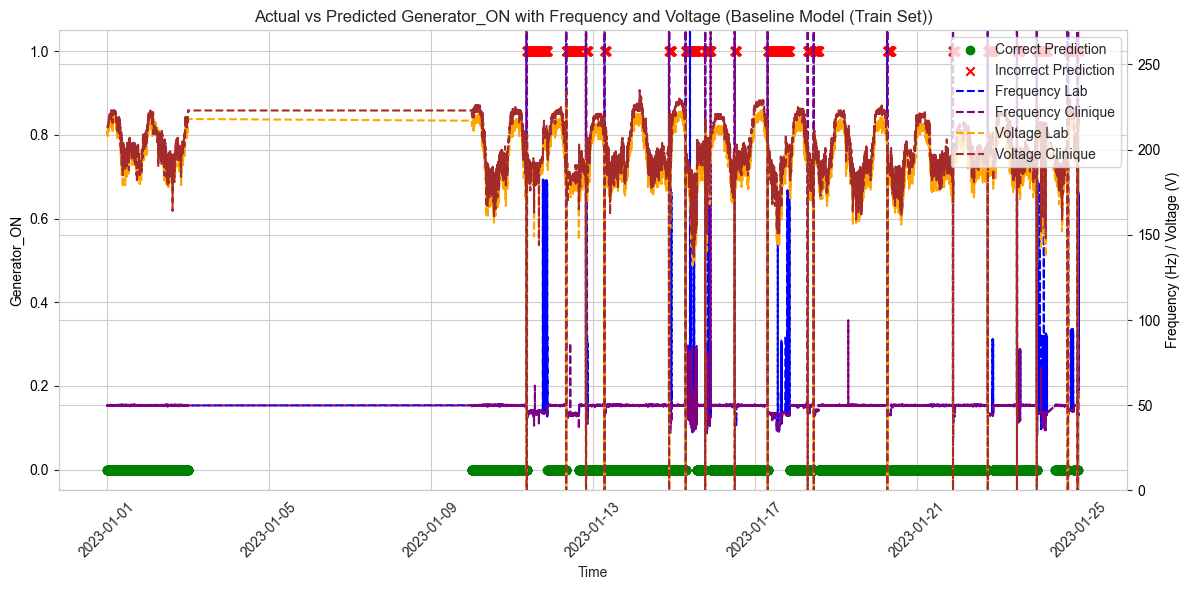

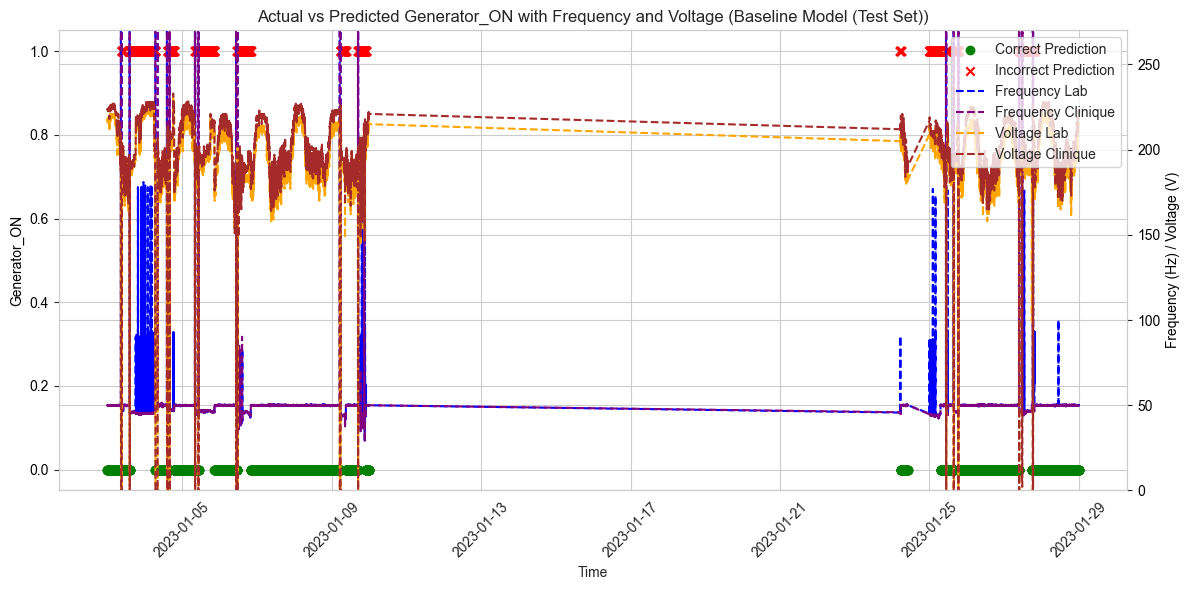

In [32]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)",  
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [33]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.83
Test Accuracy: 0.74


Evaluating the train set - Baseline Logistic Regression:

In [34]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8296957671957672
Confusion Matrix:
[[10030     9]
 [ 2051     6]]
Precision: 0.4
Recall: 0.002916869227029655
Train data prediction distribution:
prediction
0    12081
1       15
Name: count, dtype: int64


Evaluating the test set - Baseline Logistic Regression:

In [35]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.7418154761904762
Confusion Matrix:
[[5963   13]
 [2069   19]]
Precision: 0.59375
Recall: 0.009099616858237548
Test data prediction distribution:
prediction
0    8032
1      32
Name: count, dtype: int64


#### *3.3. Random Forrest on the Voltage and Frequency only*

In [36]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [37]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    10039
True      2057
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [38]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[5976    0]
 [   0 2088]]
Precision: 1.0
Recall: 1.0
Test data prediction distribution:
prediction
False    5976
True     2088
Name: count, dtype: int64


#### *3.4. XG-Boost on the Voltage and Frequency only*

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:14:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
1,Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),0.941021
0,Frequency 6EF39700 (Hgr Kitatumba - Labo),0.052338
2,Voltage 6EF39700 (Hgr Kitatumba - Labo),0.003839
3,Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),0.002802


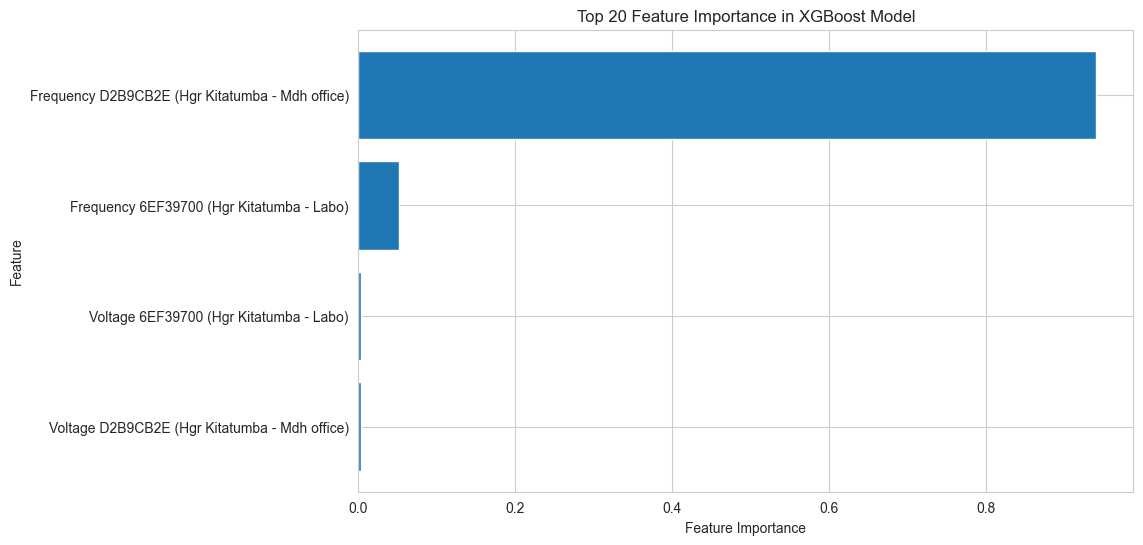

In [39]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [40]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64


In [41]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9990079365079365
Confusion Matrix:
[[5975    1]
 [   7 2081]]
Precision: 0.9995196926032661
Recall: 0.9966475095785441
Test data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64


# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [42]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

In [43]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
0,2023-01-01 00:00:00,50.0,50.0,211.0,214.0,False,False,False,True,True
1,2023-01-01 00:02:00,49.7,49.7,209.0,214.0,False,False,False,True,True
2,2023-01-01 00:04:00,50.2,50.1,209.0,214.0,False,False,False,True,True
3,2023-01-01 00:06:00,50.1,50.1,211.0,214.0,False,False,False,True,True
4,2023-01-01 00:08:00,49.7,49.7,209.0,214.0,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,61.1,45.2,206.0,212.0,True,False,False,True,True
12092,2023-01-24 05:04:00,90.0,45.4,205.0,212.0,True,False,False,True,True
12093,2023-01-24 05:06:00,45.7,45.7,205.0,211.0,True,False,False,True,True
12094,2023-01-24 05:08:00,46.1,46.2,208.0,214.0,True,False,False,True,True


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique
12096,2023-01-24 05:12:00,45.7,45.9,205.0,212.0,True,False,False,True,True
12097,2023-01-24 05:14:00,45.0,45.0,204.0,211.0,True,False,False,True,True
12098,2023-01-24 05:16:00,45.1,45.2,205.0,211.0,True,False,False,True,True
12099,2023-01-24 05:18:00,90.6,45.0,206.0,213.0,True,False,False,True,True
12100,2023-01-24 05:20:00,45.8,45.6,209.0,215.0,True,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.3,50.2,190.0,198.0,False,False,False,False,False
20156,2023-01-09 09:52:00,49.9,49.9,188.0,195.0,False,False,False,False,False
20157,2023-01-09 09:54:00,49.9,49.9,190.0,197.0,False,False,False,False,False
20158,2023-01-09 09:56:00,50.2,50.2,176.0,185.0,False,False,False,False,False


#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [44]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

'Train data for baseline:'

prediction
False    6247
True     5849
Name: count, dtype: int64

'Test data for baseline:'

prediction
False    4035
True     4029
Name: count, dtype: int64

Assessing the mean model: 

In [45]:
metrics = evaluate_model_performance(train_data_mean)

Accuracy of model: 0.4573412698412698
Confusion Matrix:
[[4861 5178]
 [1386  671]]
Precision of model: 0.11472046503675842
Recall of model: 0.32620320855614976


In [46]:
metrics = evaluate_model_performance(test_data_mean)

Accuracy of model: 0.5063244047619048
Confusion Matrix:
[[3015 2961]
 [1020 1068]]
Precision of model: 0.265078183172003
Recall of model: 0.5114942528735632


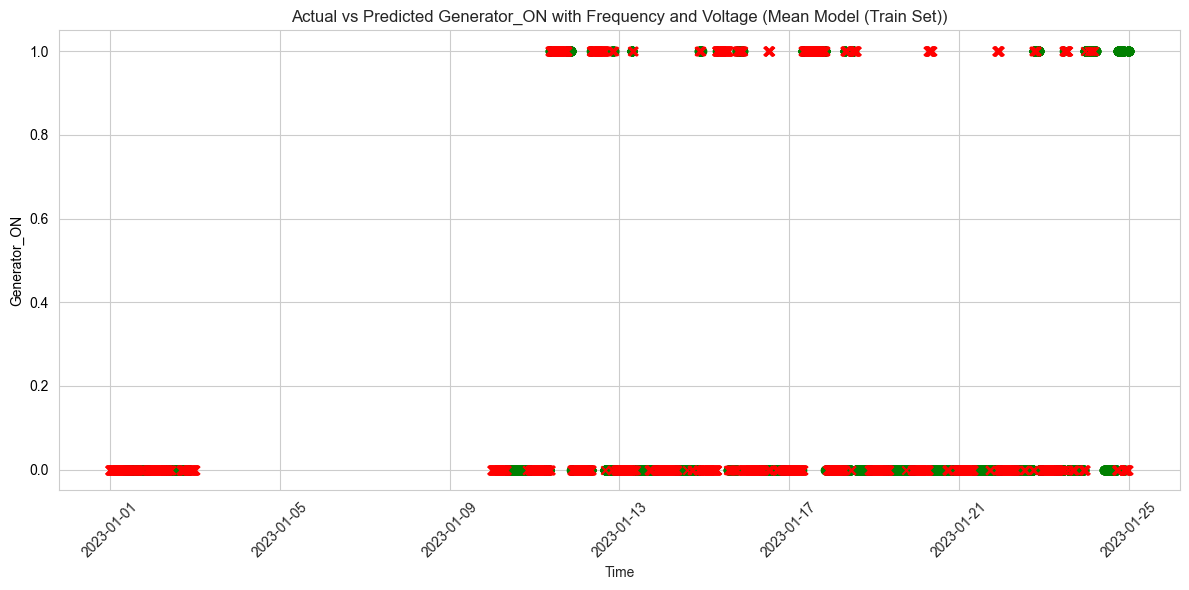

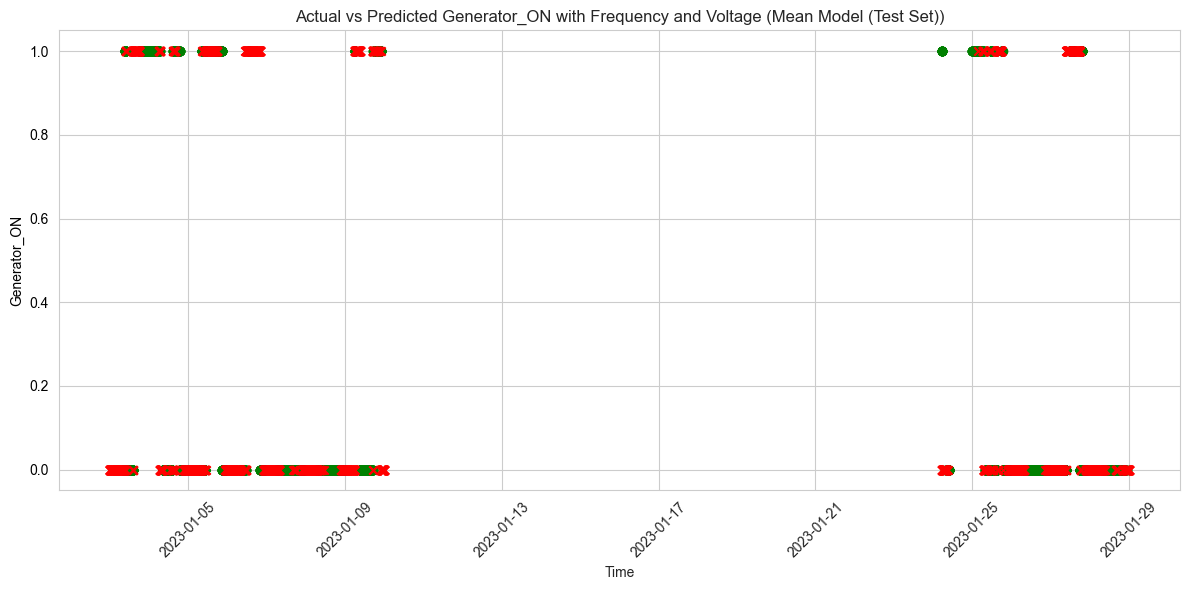

In [47]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

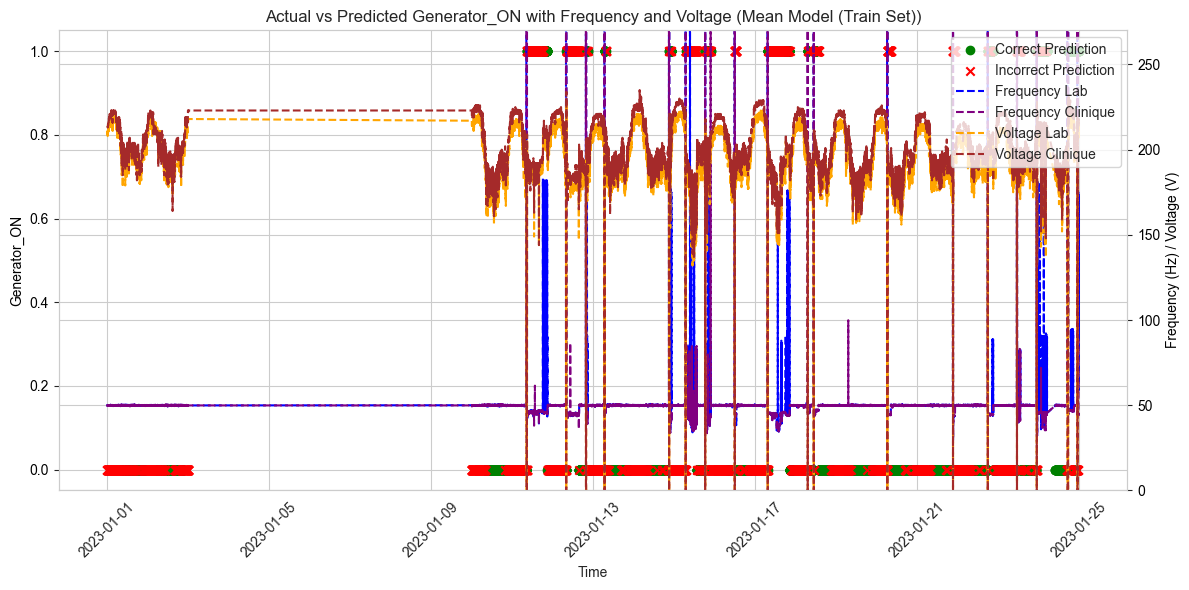

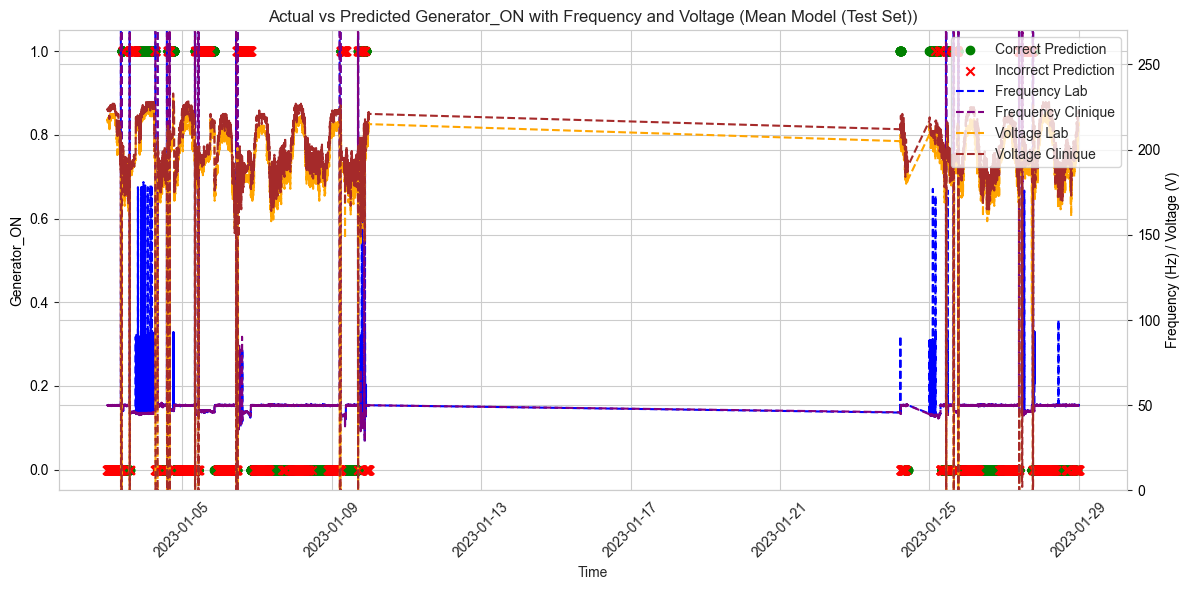

In [48]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [49]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.84
Test Accuracy: 0.75


Evaluating the train set (Logistic Regression): 

In [50]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.8379629629629629
Confusion Matrix:
[[10027    12]
 [ 1948   109]]
Precision: 0.9008264462809917
Recall: 0.052989790957705396
Train data prediction distribution:
prediction
0    11975
1      121
Name: count, dtype: int64


Evaluating the test set (Logistic Regression): 

In [51]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.7454117063492064
Confusion Matrix:
[[5952   24]
 [2029   59]]
Precision: 0.7108433734939759
Recall: 0.02825670498084291
Test data prediction distribution:
prediction
0    7981
1      83
Name: count, dtype: int64


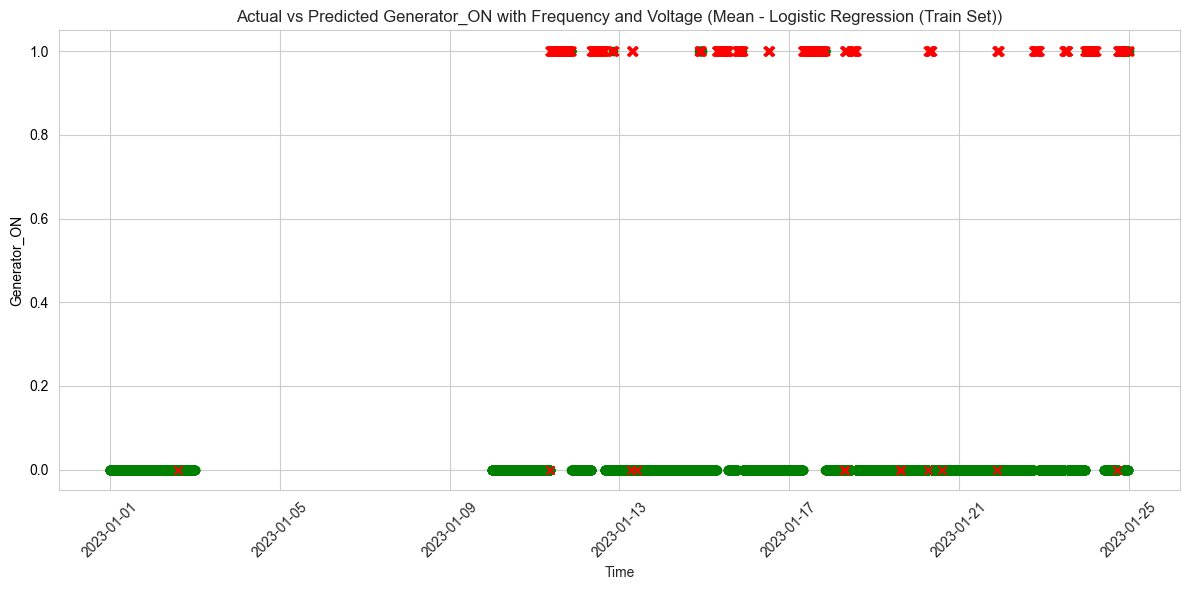

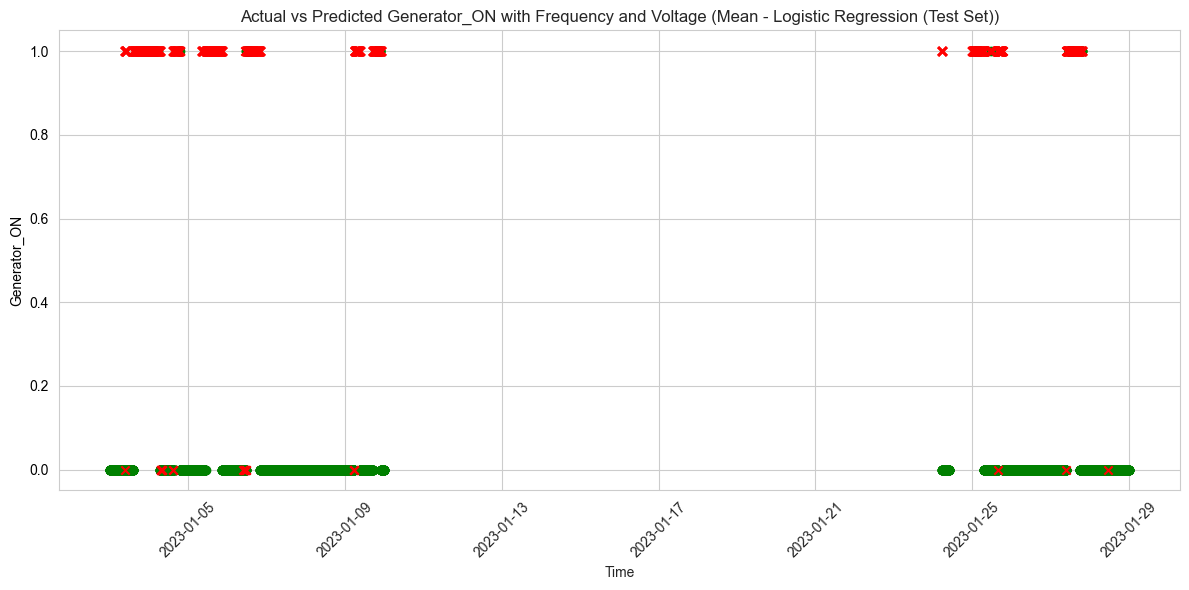

In [52]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

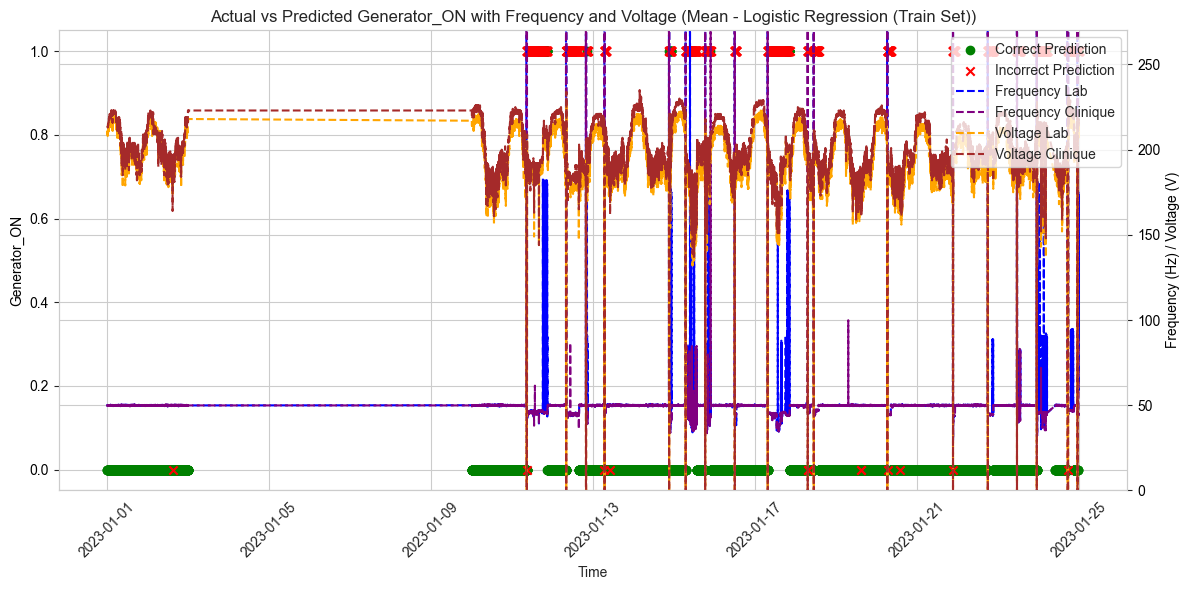

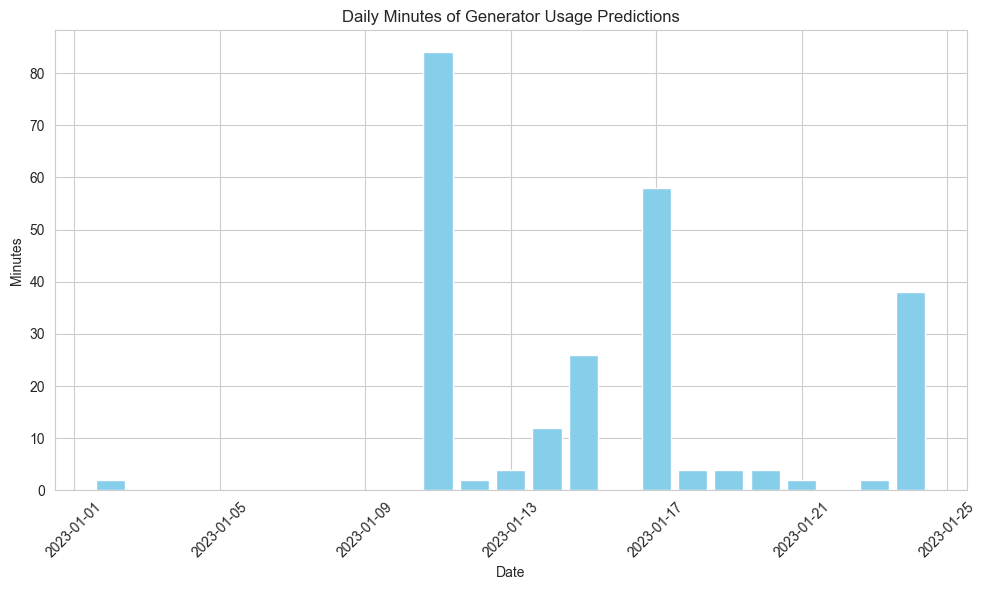

,Date,Count,Minutes,Hours
0,2023-01-02,1,2,0.033333
1,2023-01-11,42,84,1.400000
2,2023-01-12,1,2,0.033333
3,2023-01-13,2,4,0.066667
4,2023-01-14,6,12,0.200000
5,2023-01-15,13,26,0.433333
6,2023-01-17,29,58,0.966667
7,2023-01-18,2,4,0.066667
8,2023-01-19,2,4,0.066667
9,2023-01-20,2,4,0.066667


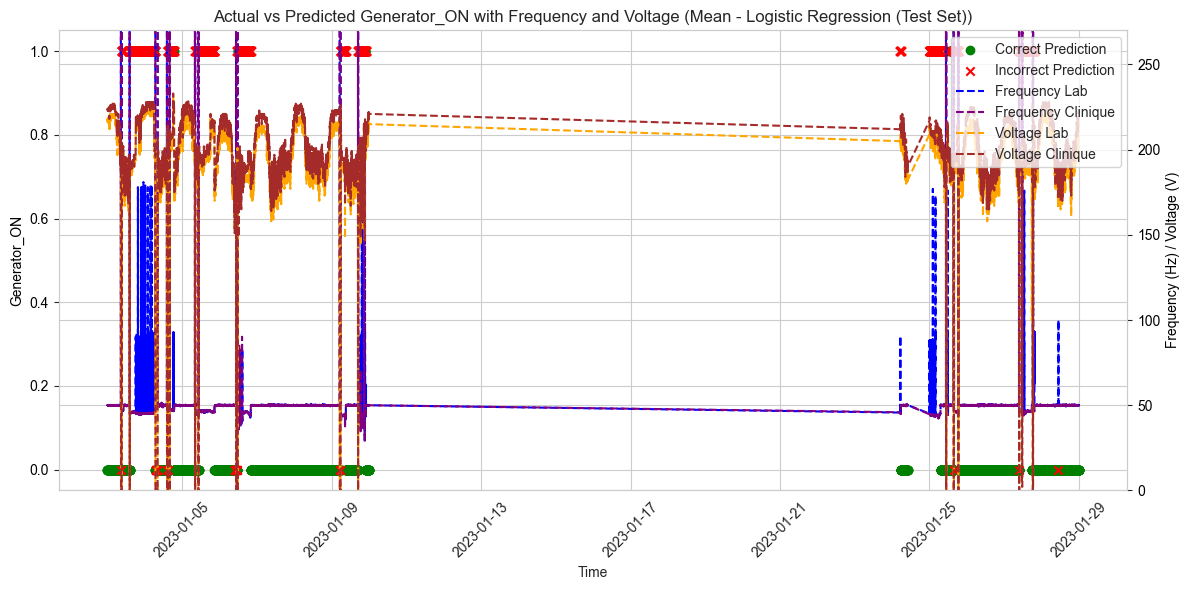

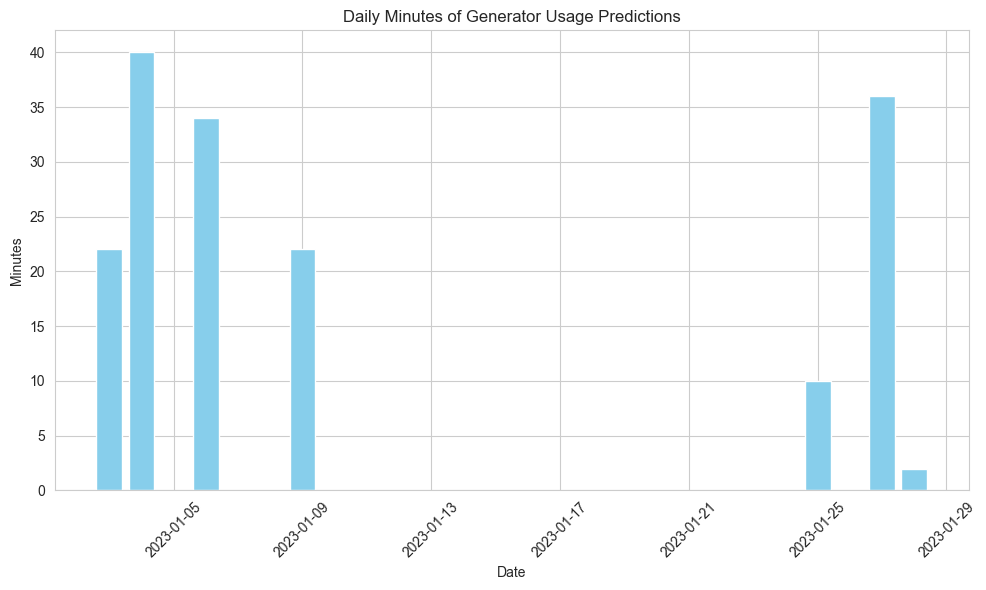

,Date,Count,Minutes,Hours
0,2023-01-03,11,22,0.366667
1,2023-01-04,20,40,0.666667
2,2023-01-06,17,34,0.566667
3,2023-01-09,11,22,0.366667
4,2023-01-25,5,10,0.166667
5,2023-01-27,18,36,0.600000
6,2023-01-28,1,2,0.033333


In [53]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [54]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [55]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    10039
True      2057
Name: count, dtype: int64


Evaluating the test set (Random Forrest): 

In [56]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9997519841269841
Confusion Matrix:
[[5974    2]
 [   0 2088]]
Precision: 0.999043062200957
Recall: 1.0
Test data prediction distribution:
prediction
False    5974
True     2090
Name: count, dtype: int64


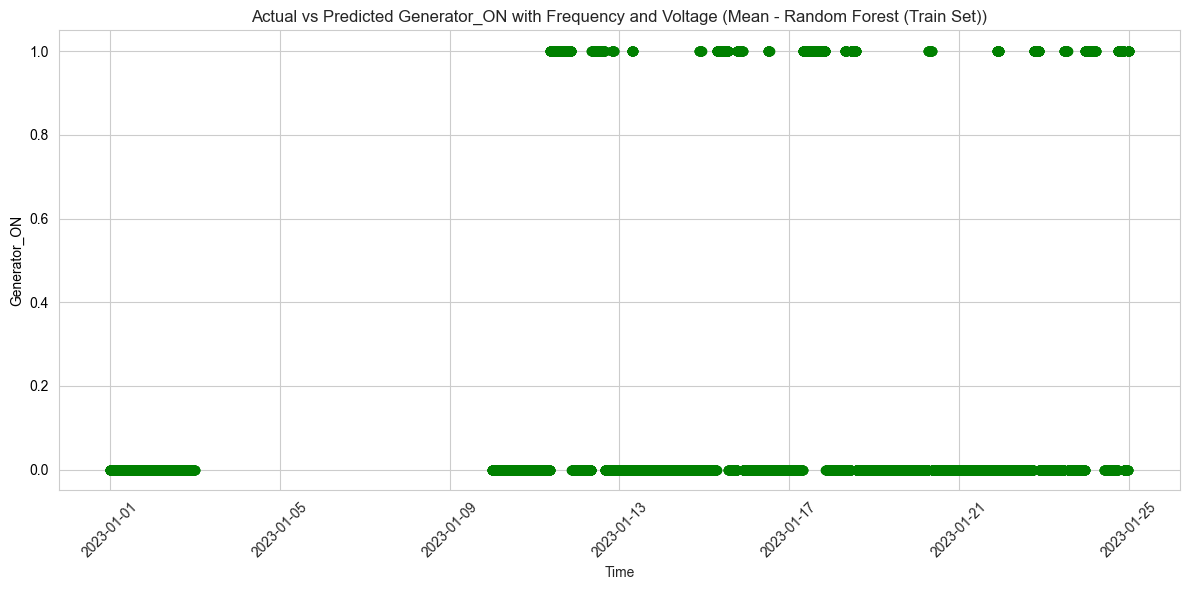

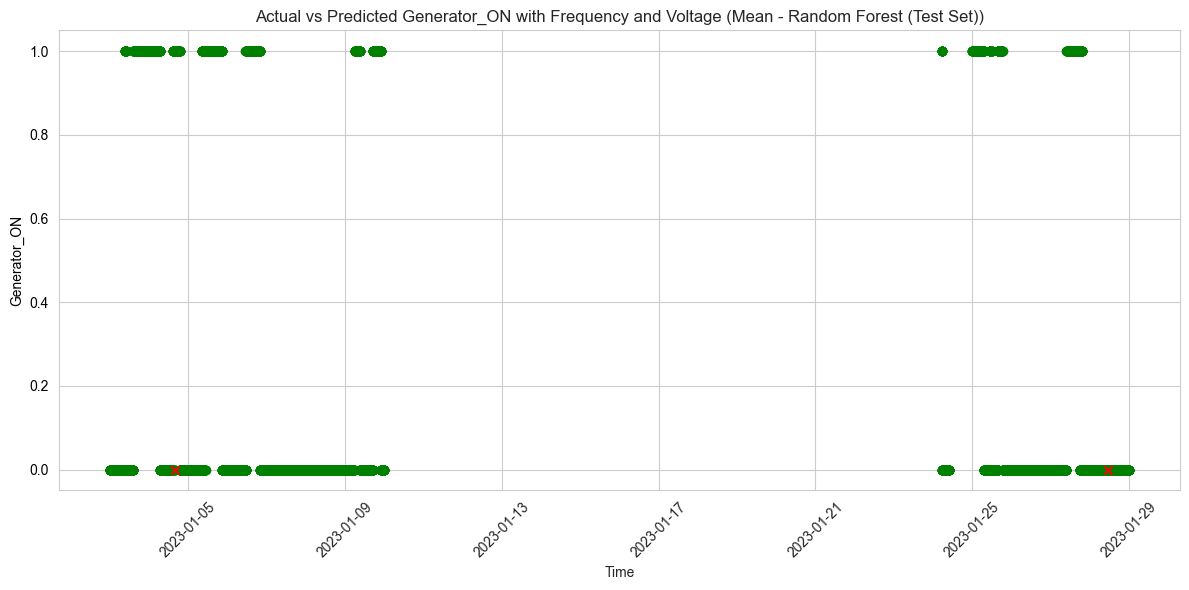

In [57]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

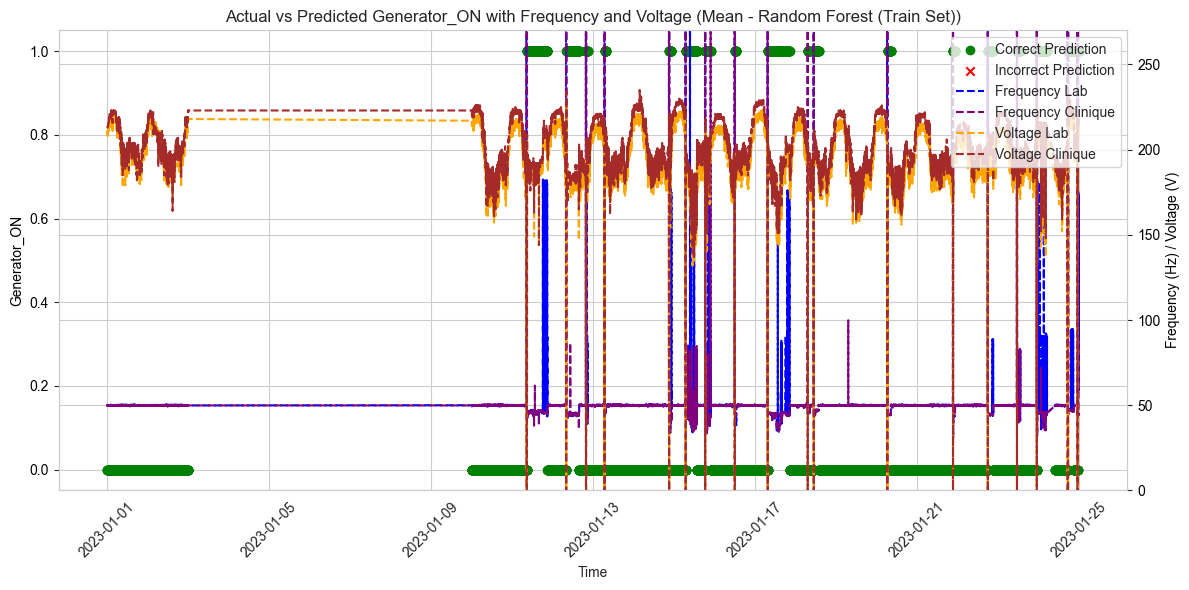

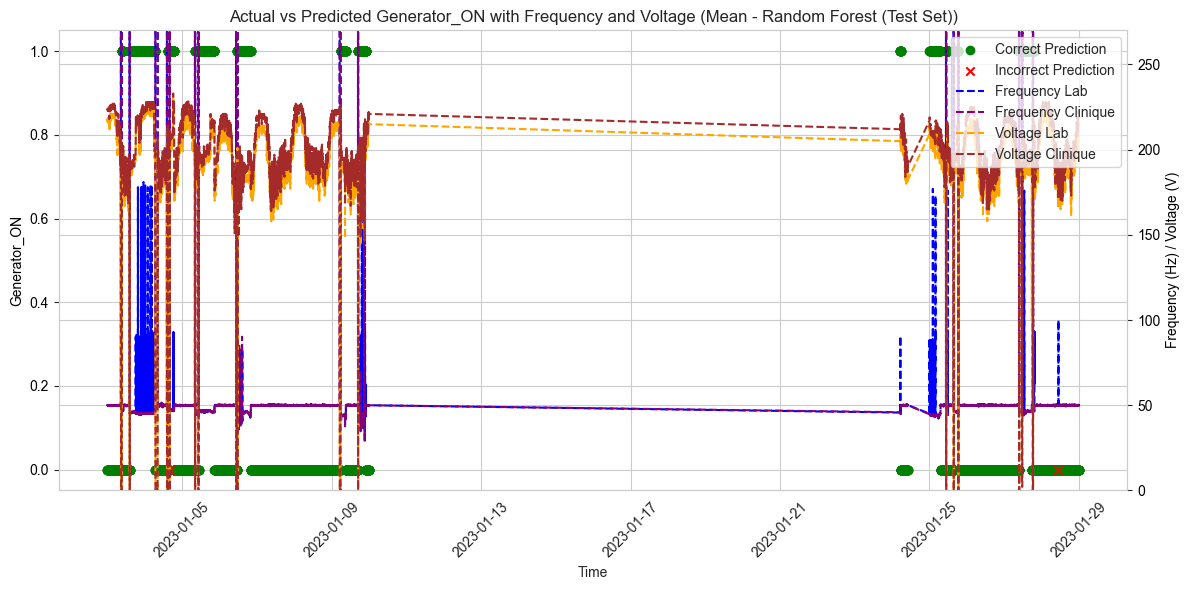

In [58]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)

In [59]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2090 minutes, or 34.83 hours within 134.40 hours


#### 4.1.4. Using Mean as a Threshold - XGBoost

Top 20 features sorted by importance (XGBoost):


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [08:14:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Feature,Importance
1,Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),0.941021
0,Frequency 6EF39700 (Hgr Kitatumba - Labo),0.052338
2,Voltage 6EF39700 (Hgr Kitatumba - Labo),0.003839
3,Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),0.002802
4,higher_freq_lab,0.000000
5,higher_freq_clinique,0.000000
6,higher_volt_lab,0.000000
7,higher_volt_clinique,0.000000


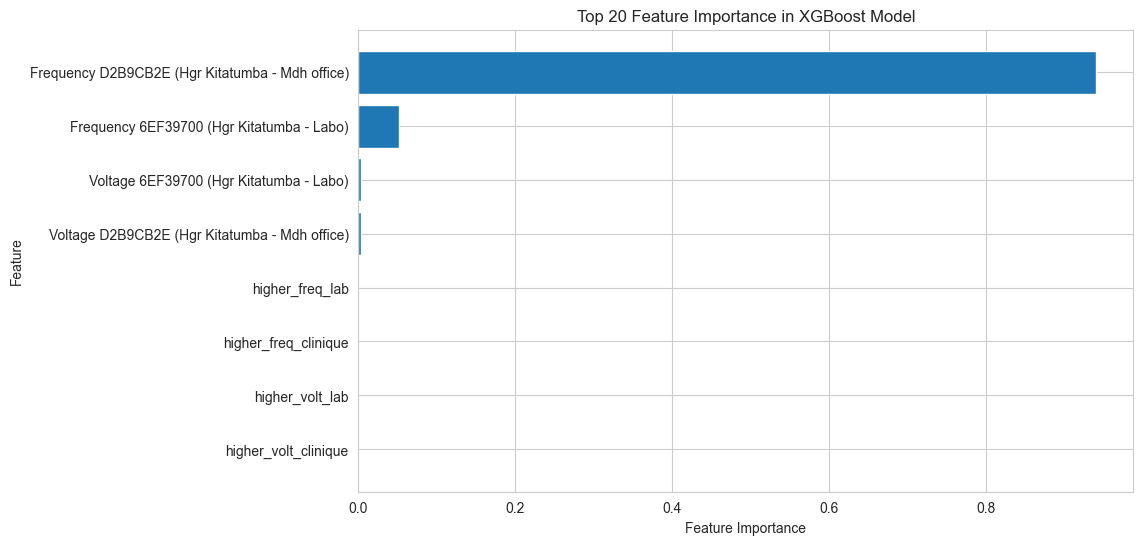

In [60]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

In [61]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64


In [62]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):
Accuracy: 0.9990079365079365
Confusion Matrix:
[[5975    1]
 [   7 2081]]
Precision: 0.9995196926032661
Recall: 0.9966475095785441
Test data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64


In [63]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2082 minutes, or 34.70 hours within 134.40 hours


### 4.2. Generating Time Series Feature

In [64]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [65]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

In [66]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
0,2023-01-01 00:00:00,50.0,50.0,211.0,214.0,False,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2023-01-01 00:02:00,49.7,49.7,209.0,214.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-01 00:04:00,50.2,50.1,209.0,214.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,2023-01-01 00:06:00,50.1,50.1,211.0,214.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 00:08:00,49.7,49.7,209.0,214.0,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,2023-01-24 05:02:00,61.1,45.2,206.0,212.0,True,False,False,True,True,...,False,False,True,False,False,False,False,False,False,False
12092,2023-01-24 05:04:00,90.0,45.4,205.0,212.0,True,False,False,True,True,...,False,False,True,False,False,False,True,False,False,False
12093,2023-01-24 05:06:00,45.7,45.7,205.0,211.0,True,False,False,True,True,...,False,False,True,False,False,False,True,False,False,False
12094,2023-01-24 05:08:00,46.1,46.2,208.0,214.0,True,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,Hour_22,Hour_23,High_delta_freq_lab,High_delta_freq_clinique,High_delta_volt_lab,High_delta_volt_clinique,Prev_High_delta_freq_lab,Prev_High_delta_freq_clinique,Prev_High_delta_volt_lab,Prev_High_delta_volt_clinique
12096,2023-01-24 05:12:00,45.7,45.9,205.0,212.0,True,False,False,True,True,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
12097,2023-01-24 05:14:00,45.0,45.0,204.0,211.0,True,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
12098,2023-01-24 05:16:00,45.1,45.2,205.0,211.0,True,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
12099,2023-01-24 05:18:00,90.6,45.0,206.0,213.0,True,False,False,True,True,...,False,False,True,False,False,False,False,False,False,False
12100,2023-01-24 05:20:00,45.8,45.6,209.0,215.0,True,False,False,True,True,...,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20155,2023-01-09 09:50:00,50.3,50.2,190.0,198.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20156,2023-01-09 09:52:00,49.9,49.9,188.0,195.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20157,2023-01-09 09:54:00,49.9,49.9,190.0,197.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20158,2023-01-09 09:56:00,50.2,50.2,176.0,185.0,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False


In [67]:
train_data_ts.columns

Index(['Time', 'Frequency 6EF39700 (Hgr Kitatumba - Labo)',
       'Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)',
       'Voltage 6EF39700 (Hgr Kitatumba - Labo)',
       'Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)', 'Generator_ON',
       'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
       'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
       'freq_delta_negative_clinique', 'volt_delta_positive_lab',
       'volt_delta_positive_clinique', 'freq_in_range_lab',
       'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
       'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
       'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
       'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
       'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
       'High_delta_freq_lab', 'High_delta_freq_clinique'

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

Train Accuracy: 0.91
Test Accuracy: 0.83
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
44,High_delta_freq_lab,3.231183
48,Prev_High_delta_freq_lab,3.081347
16,freq_in_range_lab,-2.708811
45,High_delta_freq_clinique,1.667870
25,Hour_5,-1.496940
17,volt_in_range_lab,1.431426
32,Hour_12,1.340695
31,Hour_11,1.205069
19,volt_in_range_clinique,1.204677
18,freq_in_range_clinique,-1.201324


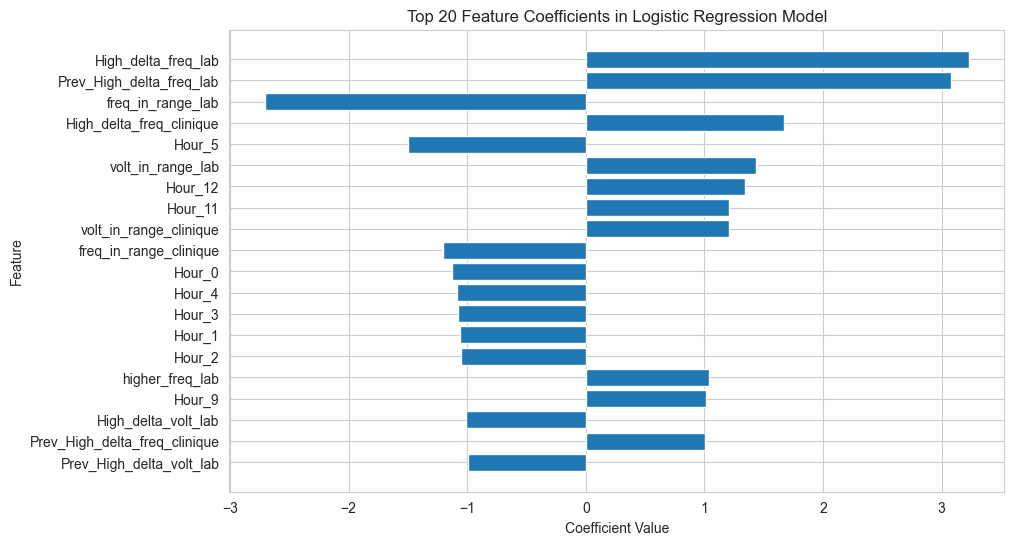

In [68]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [69]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 0.9065806878306878
Confusion Matrix:
[[9988   51]
 [1079  978]]
Precision: 0.9504373177842566
Recall: 0.47544968400583376
Train data prediction distribution:
prediction
False    11067
True      1029
Name: count, dtype: int64


In [70]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.8287450396825397
Confusion Matrix:
[[5931   45]
 [1336  752]]
Precision: 0.9435382685069009
Recall: 0.36015325670498083
Test data prediction distribution:
prediction
False    7267
True      797
Name: count, dtype: int64


In [71]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 1029 minutes, or 17.15 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 797 minutes, or 13.28 hours within 134.40 hours


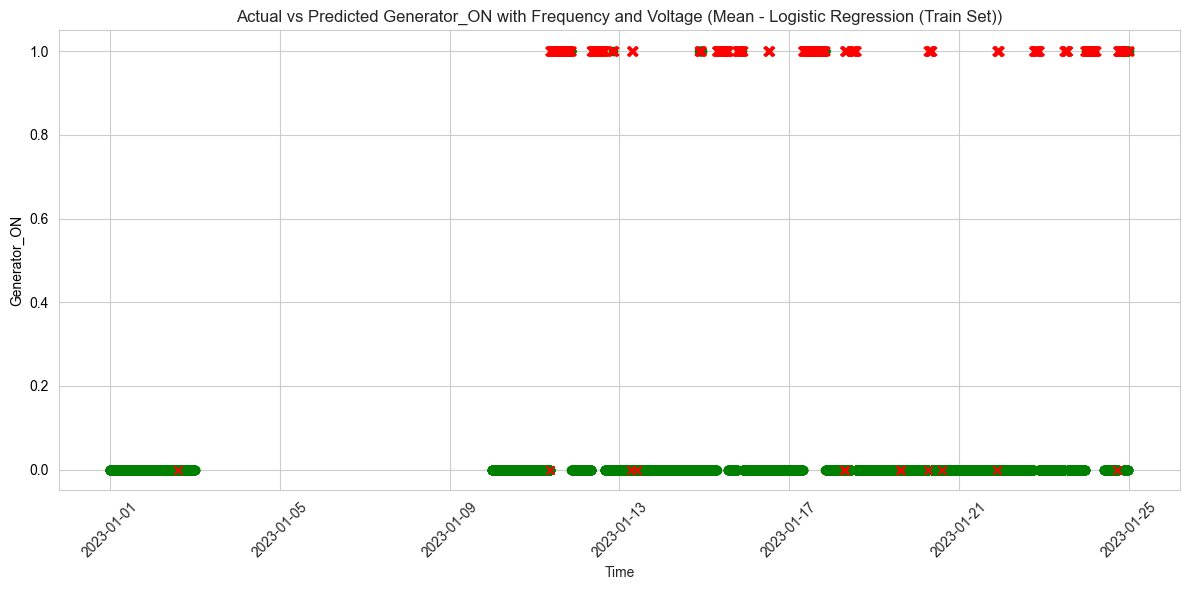

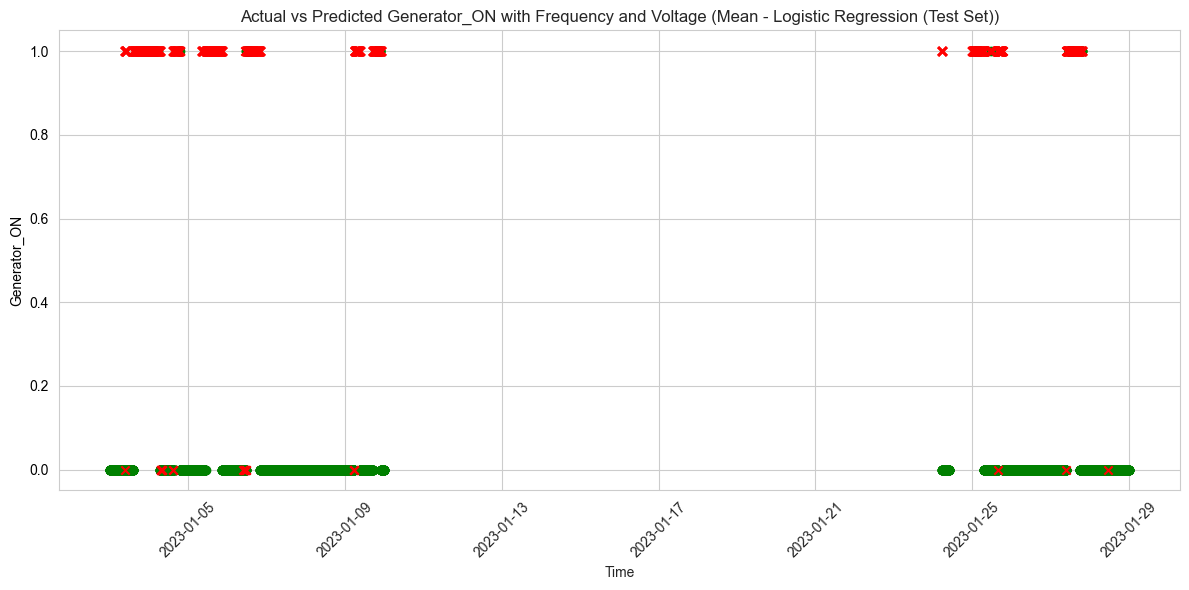

In [72]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

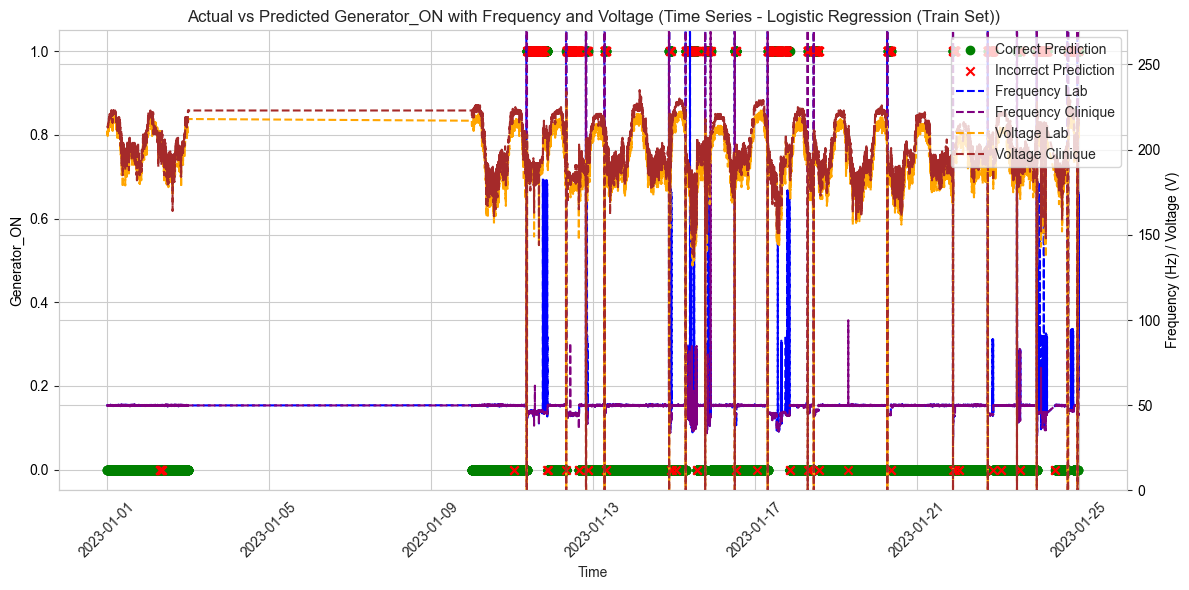

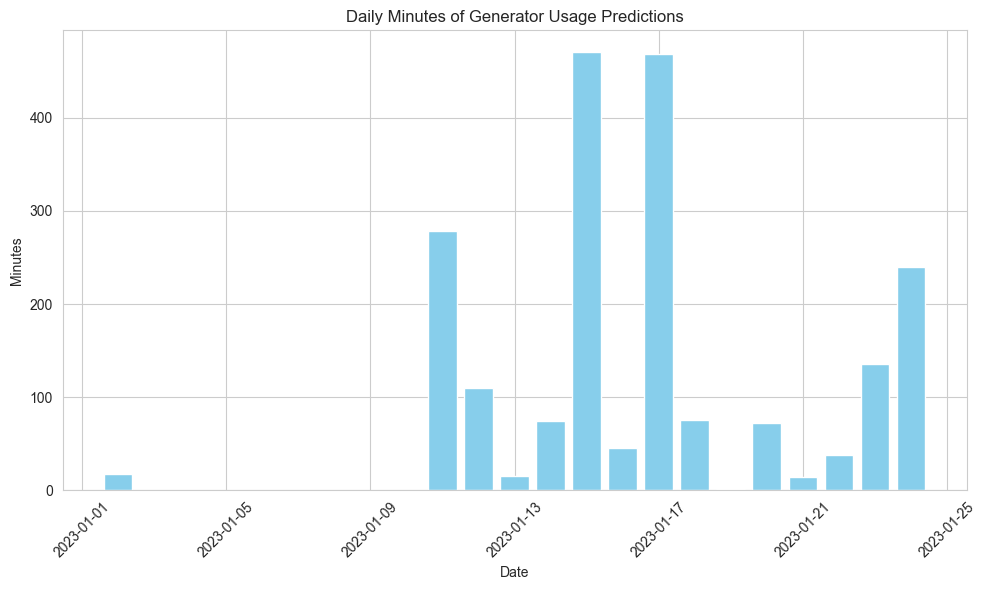

,Date,Count,Minutes,Hours
0,2023-01-02,9,18,0.300000
1,2023-01-11,139,278,4.633333
2,2023-01-12,55,110,1.833333
3,2023-01-13,8,16,0.266667
4,2023-01-14,37,74,1.233333
5,2023-01-15,235,470,7.833333
6,2023-01-16,23,46,0.766667
7,2023-01-17,234,468,7.800000
8,2023-01-18,38,76,1.266667
9,2023-01-19,1,2,0.033333


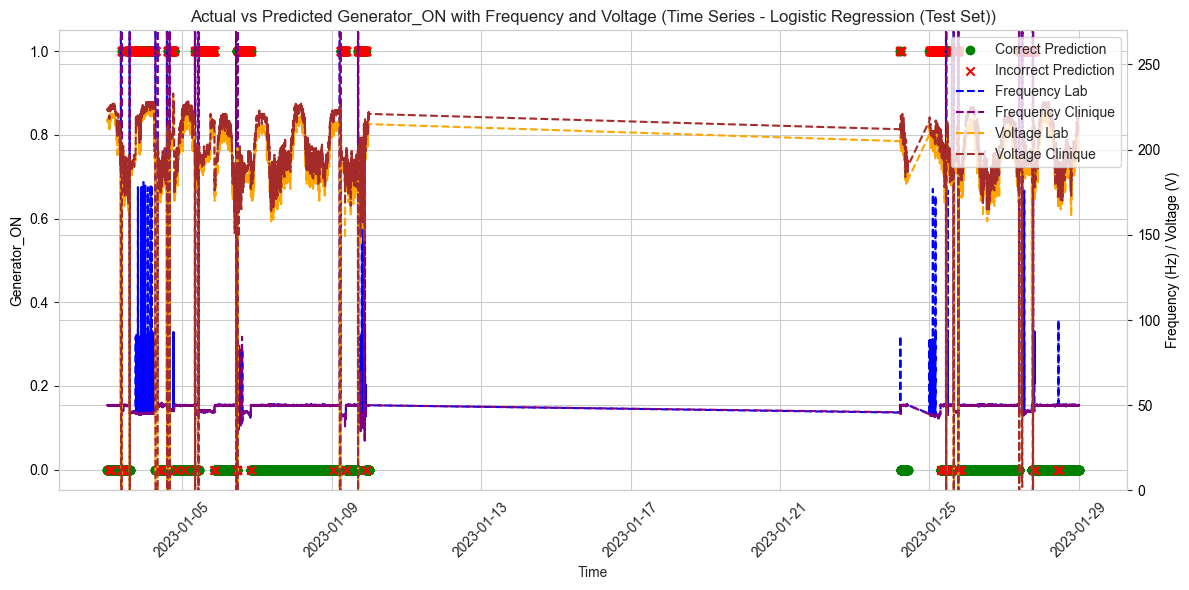

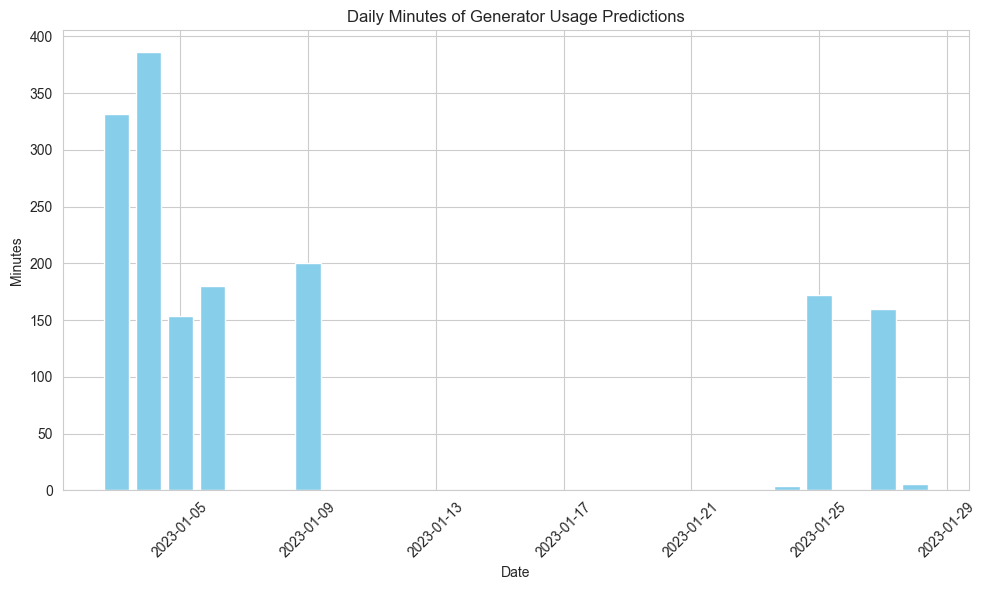

,Date,Count,Minutes,Hours
0,2023-01-03,166,332,5.533333
1,2023-01-04,193,386,6.433333
2,2023-01-05,77,154,2.566667
3,2023-01-06,90,180,3.000000
4,2023-01-09,100,200,3.333333
5,2023-01-24,2,4,0.066667
6,2023-01-25,86,172,2.866667
7,2023-01-27,80,160,2.666667
8,2023-01-28,3,6,0.100000


In [73]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

Top 15 features sorted by importance:


,Feature,Importance
1,Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),0.469519
0,Frequency 6EF39700 (Hgr Kitatumba - Labo),0.343138
48,Prev_High_delta_freq_lab,0.029578
44,High_delta_freq_lab,0.028621
8,Freq_delta_lab,0.021027
16,freq_in_range_lab,0.018172
9,Freq_delta_clinique,0.016080
3,Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),0.010413
2,Voltage 6EF39700 (Hgr Kitatumba - Labo),0.009475
45,High_delta_freq_clinique,0.005058


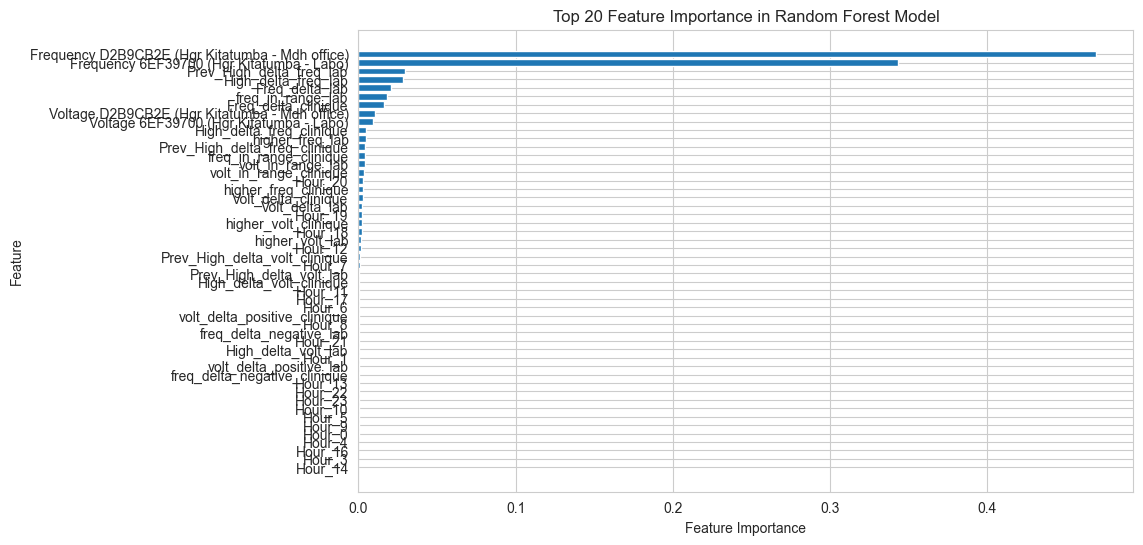

In [74]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

In [75]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    10039
True      2057
Name: count, dtype: int64


In [76]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:
Accuracy: 0.9998759920634921
Confusion Matrix:
[[5975    1]
 [   0 2088]]
Precision: 0.9995213020584012
Recall: 1.0
Test data prediction distribution:
prediction
False    5975
True     2089
Name: count, dtype: int64


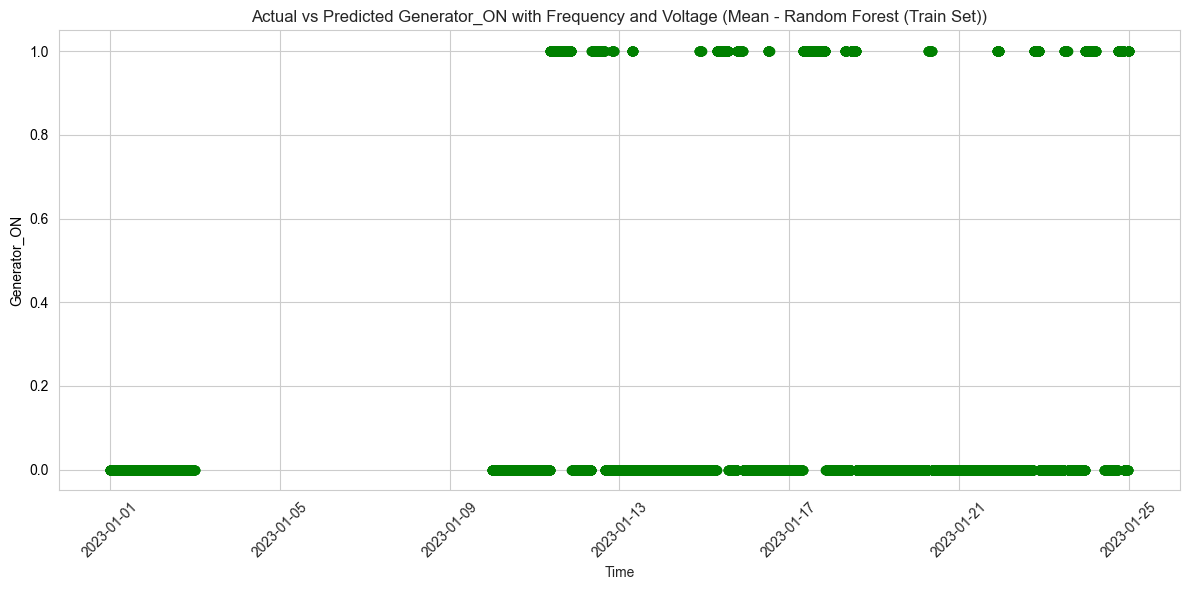

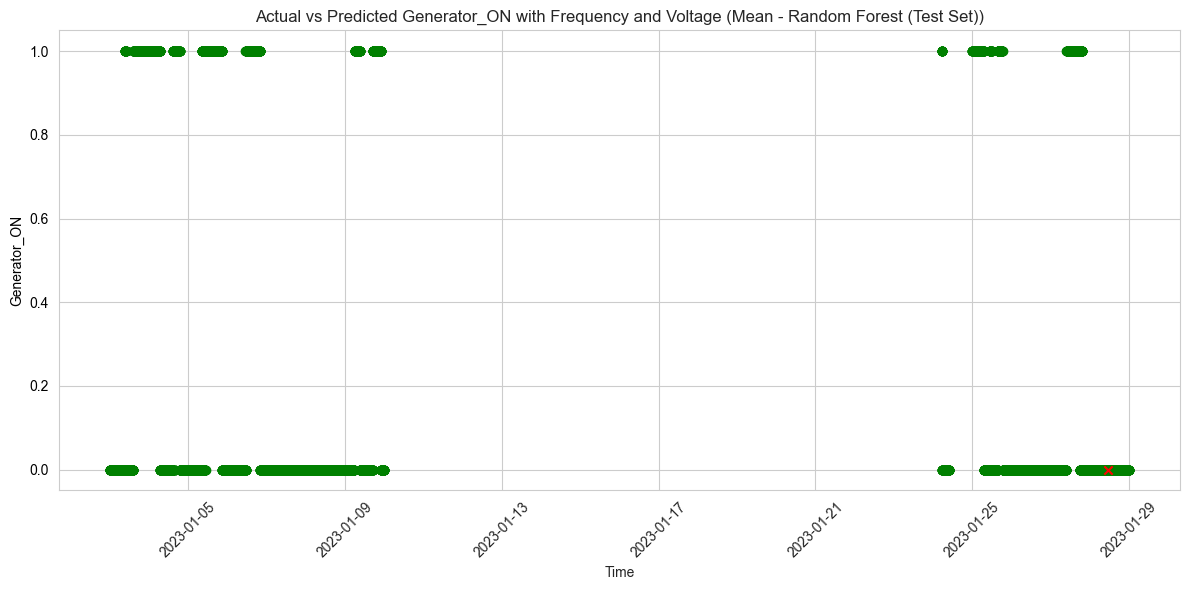

In [77]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

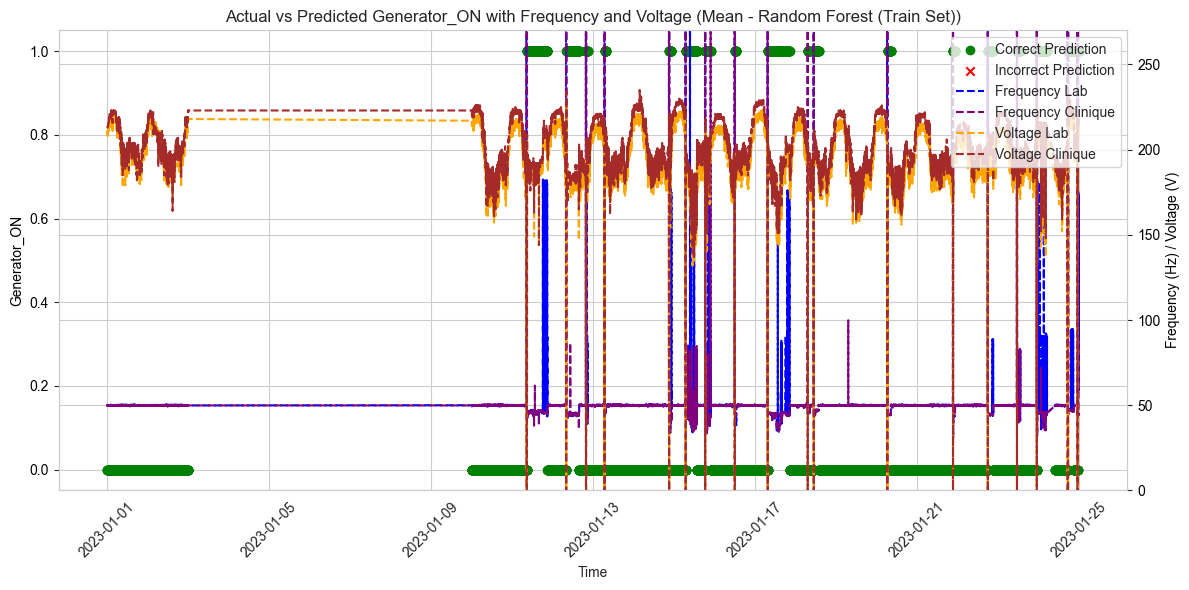

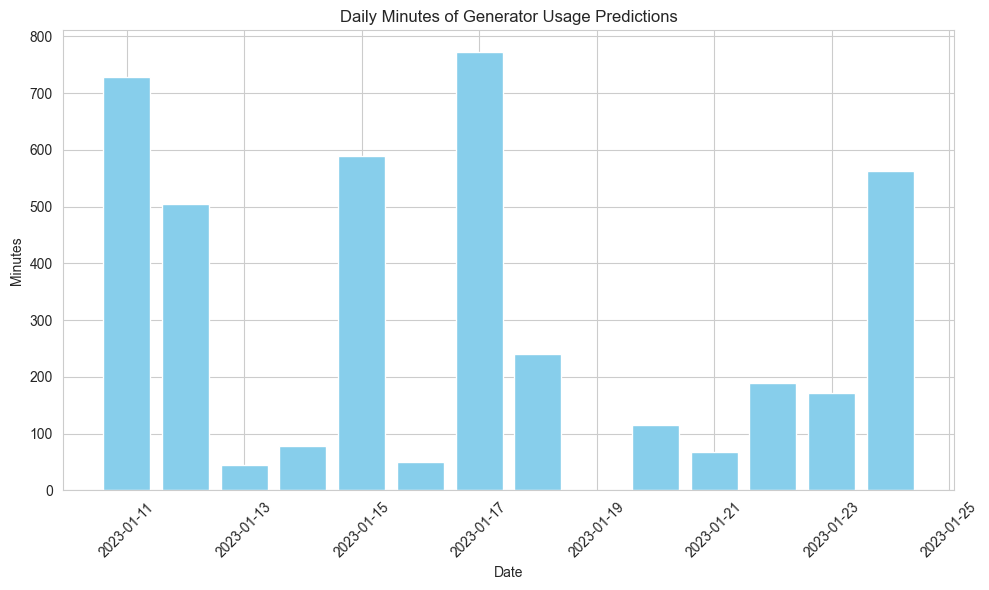

,Date,Count,Minutes,Hours
0,2023-01-11,364,728,12.133333
1,2023-01-12,252,504,8.400000
2,2023-01-13,22,44,0.733333
3,2023-01-14,39,78,1.300000
4,2023-01-15,295,590,9.833333
5,2023-01-16,25,50,0.833333
6,2023-01-17,386,772,12.866667
7,2023-01-18,120,240,4.000000
8,2023-01-20,58,116,1.933333
9,2023-01-21,34,68,1.133333


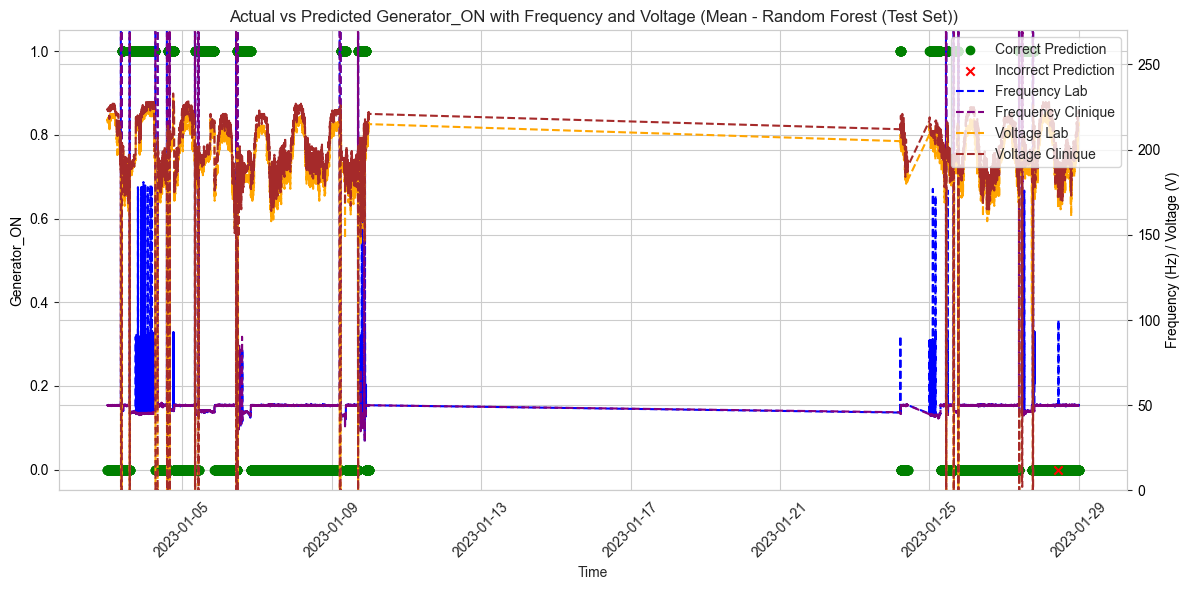

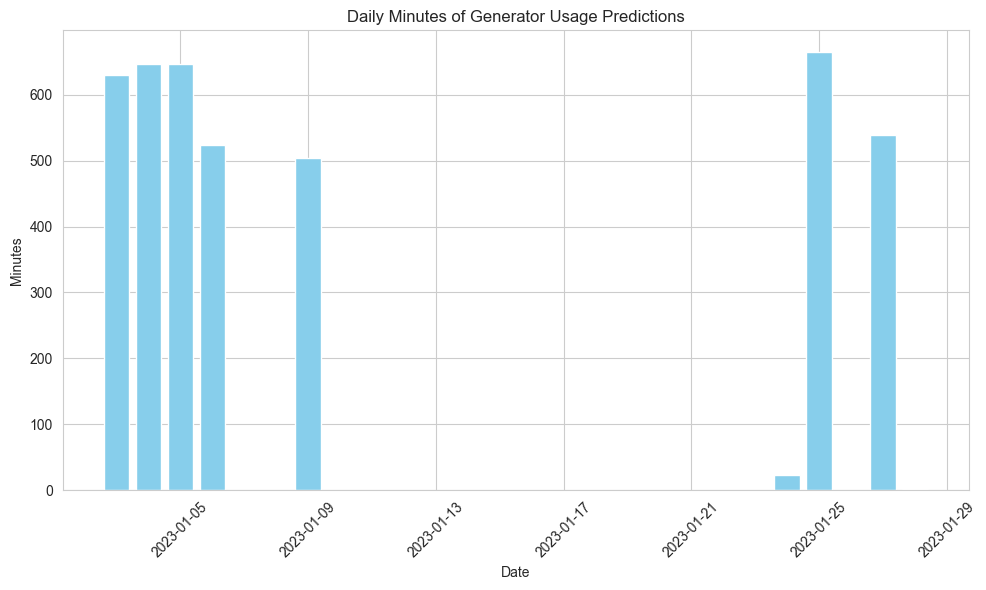

,Date,Count,Minutes,Hours
0,2023-01-03,315,630,10.500000
1,2023-01-04,323,646,10.766667
2,2023-01-05,323,646,10.766667
3,2023-01-06,262,524,8.733333
4,2023-01-09,252,504,8.400000
5,2023-01-24,12,24,0.400000
6,2023-01-25,332,664,11.066667
7,2023-01-27,269,538,8.966667
8,2023-01-28,1,2,0.033333


In [78]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

In [79]:
train_data_ts_rf['Generator_ON'].dtype

dtype('bool')

In [80]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2089 minutes, or 34.82 hours within 134.40 hours


#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [81]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(train_data_ts_boost, test_data_ts_boost, train_data_base, columns_to_compare)


# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_ts_boost[feature_columns]
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns]
y_test = test_data_ts_boost['Generator_ON']

X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
X_train['Prev_High_delta_volt_lab'] = pd.to_numeric(X_train['Prev_High_delta_volt_lab'], errors='coerce')
X_train['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_train['Prev_High_delta_volt_clinique'], errors='coerce')

X_test['Prev_High_delta_freq_lab'] = pd.to_numeric(X_test['Prev_High_delta_freq_lab'], errors='coerce')
X_test['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_test['Prev_High_delta_freq_clinique'], errors='coerce')
X_test['Prev_High_delta_volt_lab'] = pd.to_numeric(X_test['Prev_High_delta_volt_lab'], errors='coerce')
X_test['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_test['Prev_High_delta_volt_clinique'], errors='coerce')


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_36021/3060535340.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_36021/3060535340.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
/var/folders/fz/752v568s4vs79b77

#### This section is for XGBoost parameter search using cross validation

In [82]:

'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature

In [83]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      5976
        True       1.00      1.00      1.00      2088

    accuracy                           1.00      8064
   macro avg       1.00      1.00      1.00      8064
weighted avg       1.00      1.00      1.00      8064

AUC-ROC Score:
1.0
Confusion Matrix:
[[5975    1]
 [   0 2088]]


In [84]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64


In [85]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):
Accuracy: 0.9998759920634921
Confusion Matrix:
[[5975    1]
 [   0 2088]]
Precision: 0.9995213020584012
Recall: 1.0
Test data prediction distribution (XGBoost):
prediction
0    5975
1    2089
Name: count, dtype: int64


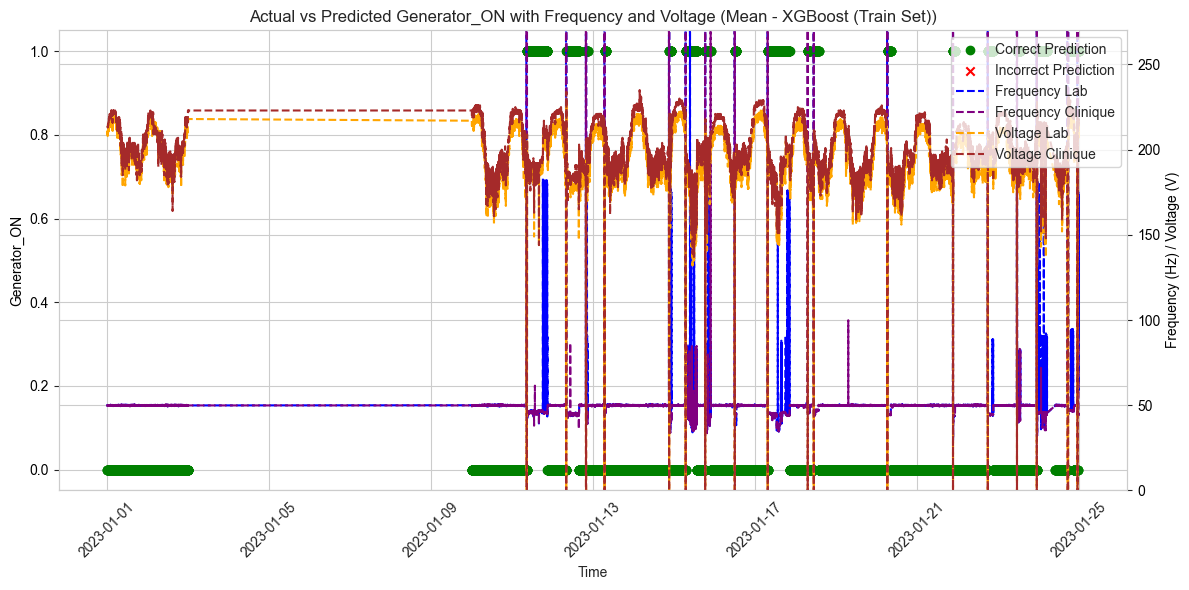

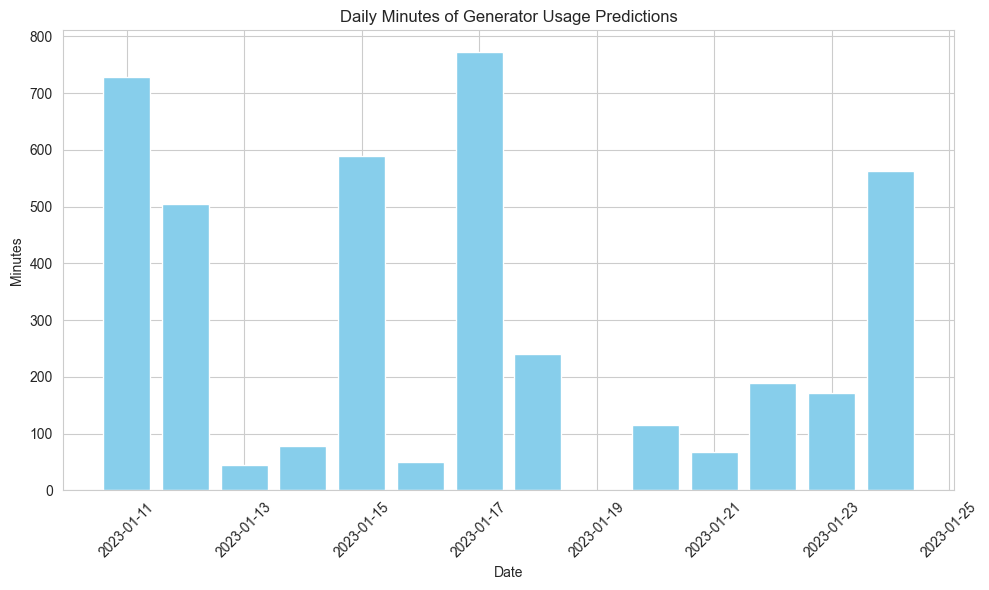

,Date,Count,Minutes,Hours
0,2023-01-11,364,728,12.133333
1,2023-01-12,252,504,8.400000
2,2023-01-13,22,44,0.733333
3,2023-01-14,39,78,1.300000
4,2023-01-15,295,590,9.833333
5,2023-01-16,25,50,0.833333
6,2023-01-17,386,772,12.866667
7,2023-01-18,120,240,4.000000
8,2023-01-20,58,116,1.933333
9,2023-01-21,34,68,1.133333


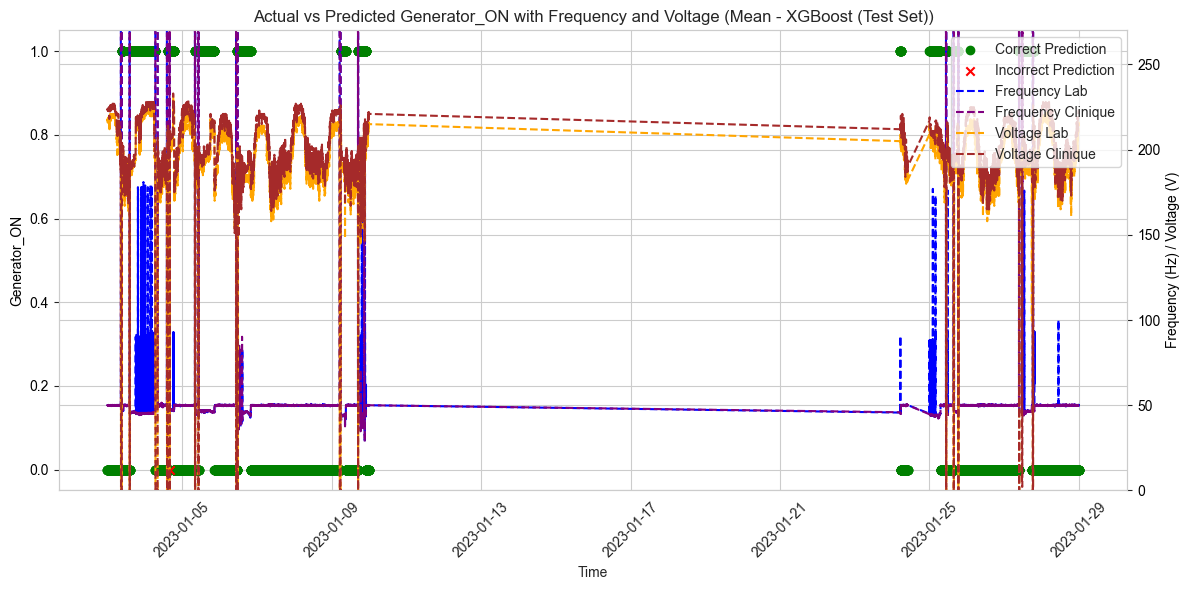

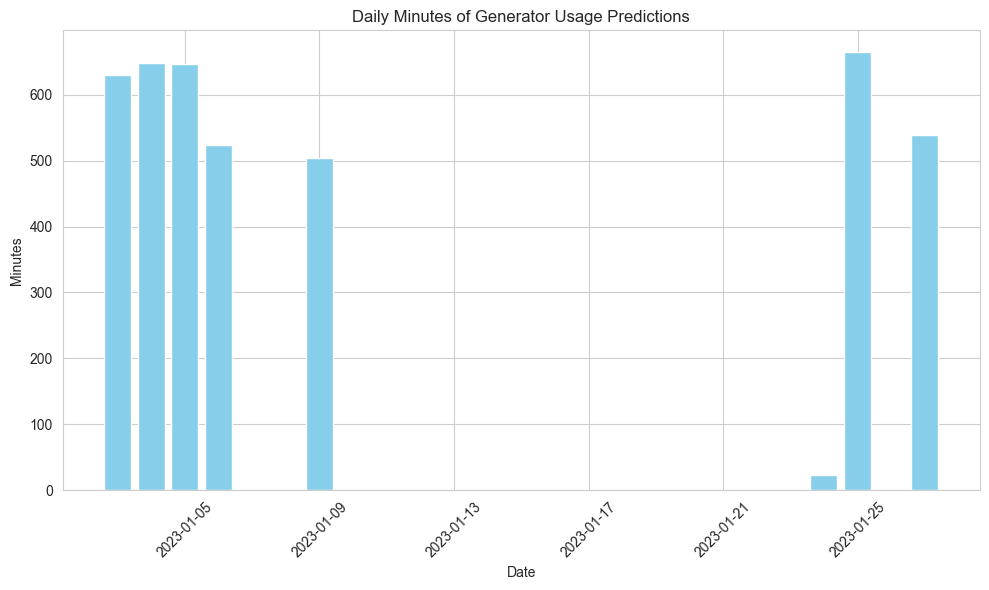

,Date,Count,Minutes,Hours
0,2023-01-03,315,630,10.500000
1,2023-01-04,324,648,10.800000
2,2023-01-05,323,646,10.766667
3,2023-01-06,262,524,8.733333
4,2023-01-09,252,504,8.400000
5,2023-01-24,12,24,0.400000
6,2023-01-25,332,664,11.066667
7,2023-01-27,269,538,8.966667


In [86]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

In [87]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2089 minutes, or 34.82 hours within 134.40 hours


### 4.3. Correlation Feature

In this section we're applying additional feature using the : 
- Hidden Markov Model : Detecting states

In [88]:
### Applying Hidden Markov Model

# Insert variables
n_states = 5
hmm_columns = [freq_a, freq_b, volt_a, volt_b]

# Make copies of original train and test sets
train_data_ts_co = train_data_ts.copy()
test_data_ts_co = test_data_ts.copy()

# Sort by Time
train_data_ts_co.sort_values('Time', ascending=True, inplace=True)
test_data_ts_co.sort_values('Time', ascending=True, inplace=True)

# Clean NaNs, infs, and low-variance columns
valid_hmm_columns = []

for col in hmm_columns:
    if col in train_data_ts_co.columns and col in test_data_ts_co.columns:
        values_train = train_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)
        values_test = test_data_ts_co[col].replace([np.inf, -np.inf], 0).fillna(0)

        if values_train.std() < 1e-3:
            print(f"⚠️ Column {col} has too low variance (std={values_train.std():.5f}), skipping HMM fitting.")
        else:
            train_data_ts_co[col] = values_train
            test_data_ts_co[col] = values_test
            valid_hmm_columns.append(col)

hmm_columns = valid_hmm_columns  # update hmm_columns

# Train HMMs on train set
train_data_ts_co, hmm_models, hmm_features = generate_hmm(
    train_data_ts_co,
    hmm_columns,
    n_states=n_states
)

# Apply HMMs to test set
def apply_hmm(df, columns, hmm_models):
    """
    Apply trained HMM models to a new dataset and generate one-hot encoded HMM states.

    Parameters:
    - df (DataFrame): The DataFrame to apply HMMs to.
    - columns (list): List of feature columns to apply HMMs.
    - hmm_models (dict): Trained HMM models from the training set.

    Returns:
    - df_result (DataFrame): DataFrame with added HMM states and one-hot encoded features.
    """
    df_result = df.copy()
    hmm_feature_cols = []

    for col in columns:
        if col not in df_result.columns:
            print(f"⚠️ Column {col} missing in DataFrame. Skipping...")
            continue

        X = df_result[col].replace([np.inf, -np.inf], 0).fillna(0).to_numpy().reshape(-1, 1)
        state_col = f'HMM_State_{col}'
        model = hmm_models.get(col)

        if model is not None:
            df_result[state_col] = model.predict(X)

            # One-hot encode HMM state
            dummies = pd.get_dummies(df_result[state_col], prefix=state_col)
            df_result = pd.concat([df_result, dummies], axis=1)
            hmm_feature_cols.extend(dummies.columns.tolist())
        else:
            print(f"⚠️ No trained HMM model found for {col}. Skipping...")

    return df_result

# Now apply
test_data_ts_co = apply_hmm(test_data_ts_co, hmm_columns, hmm_models)

# Display result
display(train_data_ts_co)
display(test_data_ts_co)

,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_1,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_2,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_3,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_4,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_0,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_1,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_2,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_3,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_4
0,2023-01-01 00:00:00,50.0,50.0,211.0,214.0,False,False,False,True,True,...,False,False,False,True,4,False,False,False,False,True
1,2023-01-01 00:02:00,49.7,49.7,209.0,214.0,False,False,False,True,True,...,False,False,False,False,0,True,False,False,False,False
2,2023-01-01 00:04:00,50.2,50.1,209.0,214.0,False,False,False,True,True,...,False,False,False,True,1,False,True,False,False,False
3,2023-01-01 00:06:00,50.1,50.1,211.0,214.0,False,False,False,True,True,...,False,False,False,False,4,False,False,False,False,True
4,2023-01-01 00:08:00,49.7,49.7,209.0,214.0,False,False,False,True,True,...,False,False,False,True,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,2023-01-24 23:50:00,87.8,44.5,214.0,216.0,True,False,False,True,True,...,False,False,False,True,0,True,False,False,False,False
11996,2023-01-24 23:52:00,59.6,44.7,216.0,219.0,True,False,False,True,True,...,False,False,False,False,1,False,True,False,False,False
11997,2023-01-24 23:54:00,88.7,45.0,217.0,219.0,True,False,False,True,True,...,False,False,False,True,4,False,False,False,False,True
11998,2023-01-24 23:56:00,88.5,44.7,216.0,219.0,True,False,False,True,True,...,False,False,False,False,0,True,False,False,False,False


,Time,Frequency 6EF39700 (Hgr Kitatumba - Labo),Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),Voltage 6EF39700 (Hgr Kitatumba - Labo),Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),Generator_ON,higher_freq_lab,higher_freq_clinique,higher_volt_lab,higher_volt_clinique,...,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_1,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_2,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_3,HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_4,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_0,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_1,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_2,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_3,HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_4
15120,2023-01-03 00:00:00,49.5,49.5,217.0,223.0,False,False,False,True,True,...,False,False,False,True,4,False,False,False,False,True
15121,2023-01-03 00:02:00,49.9,49.9,218.0,223.0,False,False,False,True,True,...,False,False,False,False,0,True,False,False,False,False
15122,2023-01-03 00:04:00,50.1,50.1,218.0,223.0,False,False,False,True,True,...,False,False,False,True,1,False,True,False,False,False
15123,2023-01-03 00:06:00,50.1,50.1,218.0,223.0,False,False,False,True,True,...,False,False,False,False,4,False,False,False,False,True
15124,2023-01-03 00:08:00,50.0,49.9,216.0,223.0,False,False,False,True,True,...,False,False,False,True,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14875,2023-01-28 23:50:00,50.0,50.0,216.0,223.0,False,False,False,True,True,...,False,False,False,True,0,True,False,False,False,False
14876,2023-01-28 23:52:00,49.9,49.9,216.0,223.0,False,False,False,True,True,...,False,False,False,False,1,False,True,False,False,False
14877,2023-01-28 23:54:00,49.9,49.9,216.0,223.0,False,False,False,True,True,...,False,False,False,True,4,False,False,False,False,True
14878,2023-01-28 23:56:00,50.0,50.0,216.0,223.0,False,False,False,True,True,...,False,False,False,False,0,True,False,False,False,False



Mean values per HMM state for Frequency 6EF39700 (Hgr Kitatumba - Labo):
Series([], Name: Frequency 6EF39700 (Hgr Kitatumba - Labo), dtype: float64)


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_36021/2959736297.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.sort_values('Time', ascending=True, inplace=True)


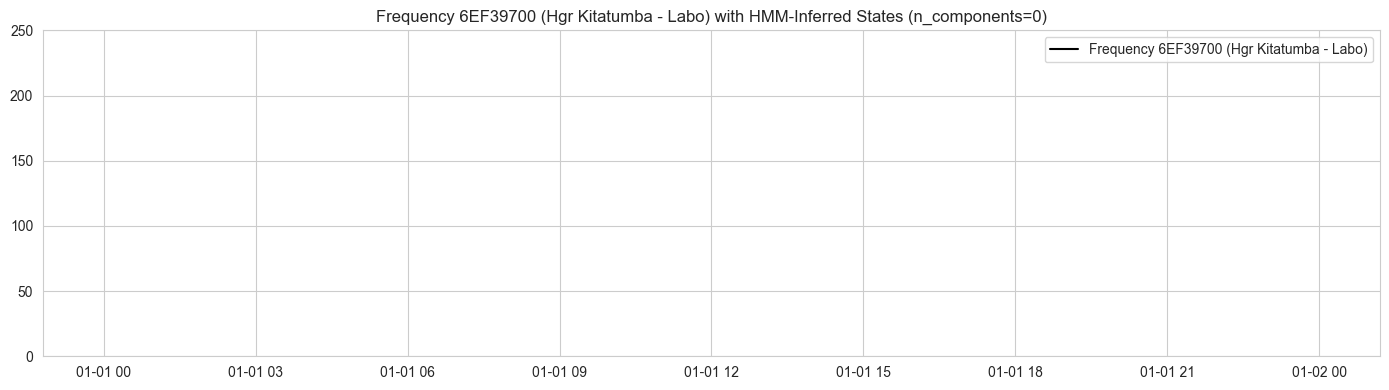


Mean values per HMM state for Frequency D2B9CB2E (Hgr Kitatumba - Mdh office):
Series([], Name: Frequency D2B9CB2E (Hgr Kitatumba - Mdh office), dtype: float64)


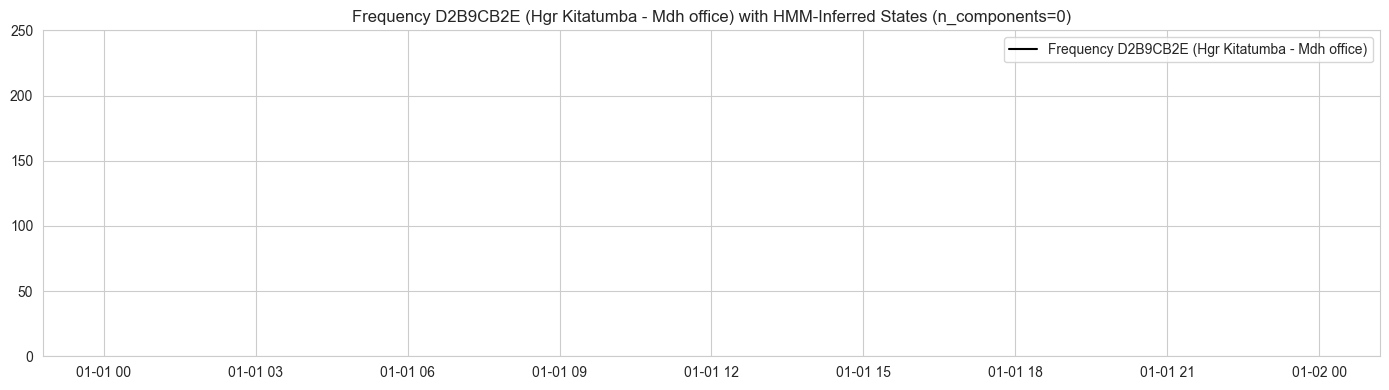


Mean values per HMM state for Voltage 6EF39700 (Hgr Kitatumba - Labo):
Series([], Name: Voltage 6EF39700 (Hgr Kitatumba - Labo), dtype: float64)


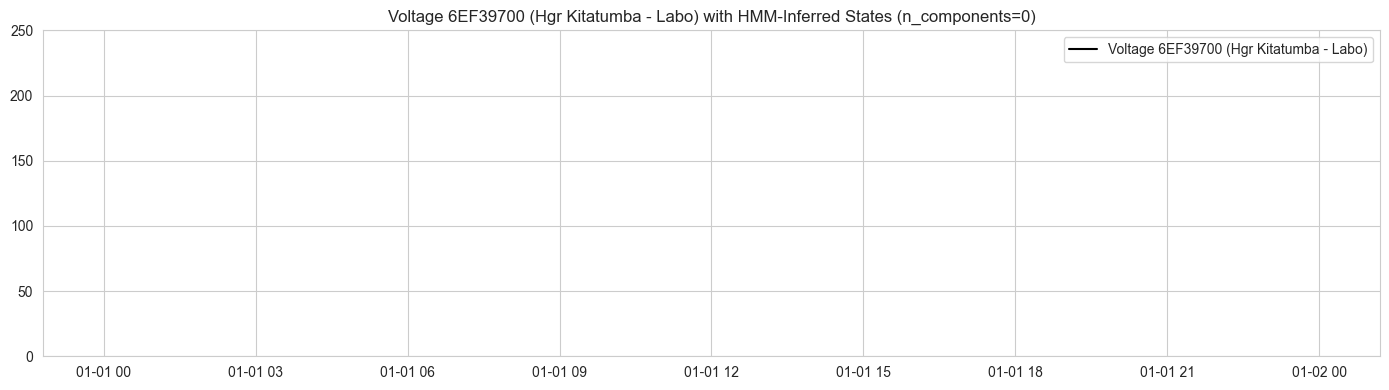


Mean values per HMM state for Voltage D2B9CB2E (Hgr Kitatumba - Mdh office):
Series([], Name: Voltage D2B9CB2E (Hgr Kitatumba - Mdh office), dtype: float64)


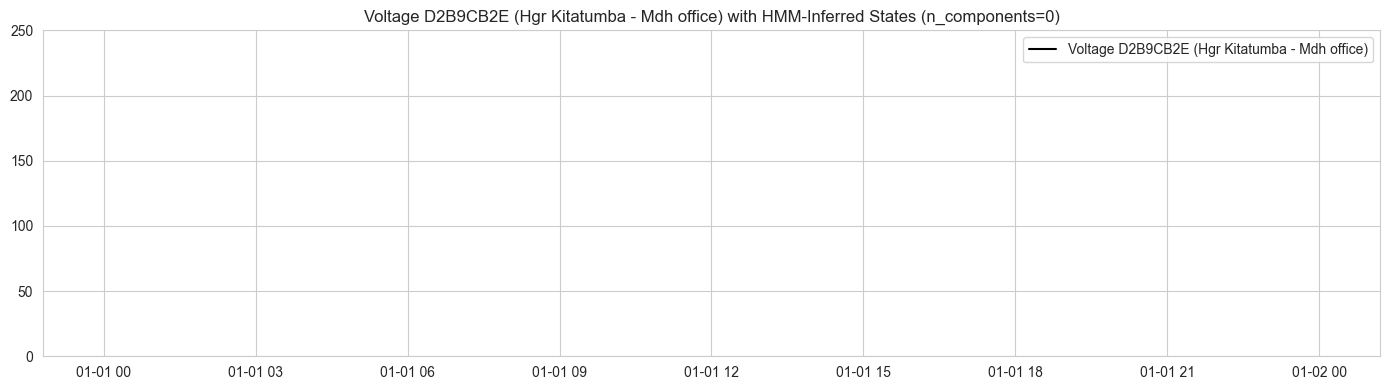

In [89]:
#### SHOWING THE RESULT OF HMM SIGNAL
    
# Create the signal
start_date = '2023-02-01 00:00:00'
finished_date = '2023-02-13 23:59:59'
filtered_data = train_data_ts_co[(train_data_ts_co['Time'] >= start_date) & (train_data_ts_co['Time'] <= finished_date)]
filtered_data.sort_values('Time', ascending=True, inplace=True)

show_hmm_result(filtered_data, hmm_columns, y_max=250)

In [90]:
hmm_features

['HMM_State_Frequency 6EF39700 (Hgr Kitatumba - Labo)_0',
 'HMM_State_Frequency 6EF39700 (Hgr Kitatumba - Labo)_1',
 'HMM_State_Frequency 6EF39700 (Hgr Kitatumba - Labo)_2',
 'HMM_State_Frequency 6EF39700 (Hgr Kitatumba - Labo)_3',
 'HMM_State_Frequency 6EF39700 (Hgr Kitatumba - Labo)_4',
 'HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)_0',
 'HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)_1',
 'HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)_2',
 'HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)_3',
 'HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - Mdh office)_4',
 'HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_0',
 'HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_1',
 'HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_2',
 'HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_3',
 'HMM_State_Voltage 6EF39700 (Hgr Kitatumba - Labo)_4',
 'HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Mdh office)_0',
 'HMM_State_Voltage D2B9CB2E (Hgr Kitatumba - Md

#### 4.3.1. Adding the Correlation functions (HMM and Ruptures)  - Logistic Regression

Train Accuracy: 1.00
Test Accuracy: 1.00
Top 20 features sorted by absolute coefficient value:


/Users/d.sitompul/Documents/GitHub/Generator_ML_Emission_Modeling/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
57,HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - ...,-4.280815
59,HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - ...,3.258351
52,HMM_State_Frequency 6EF39700 (Hgr Kitatumba - ...,-3.198363
54,HMM_State_Frequency 6EF39700 (Hgr Kitatumba - ...,3.103796
49,Prev_High_delta_freq_clinique,0.866289
48,Prev_High_delta_freq_lab,0.861868
16,freq_in_range_lab,-0.839688
44,High_delta_freq_lab,0.725405
26,Hour_6,-0.720889
37,Hour_17,-0.701347


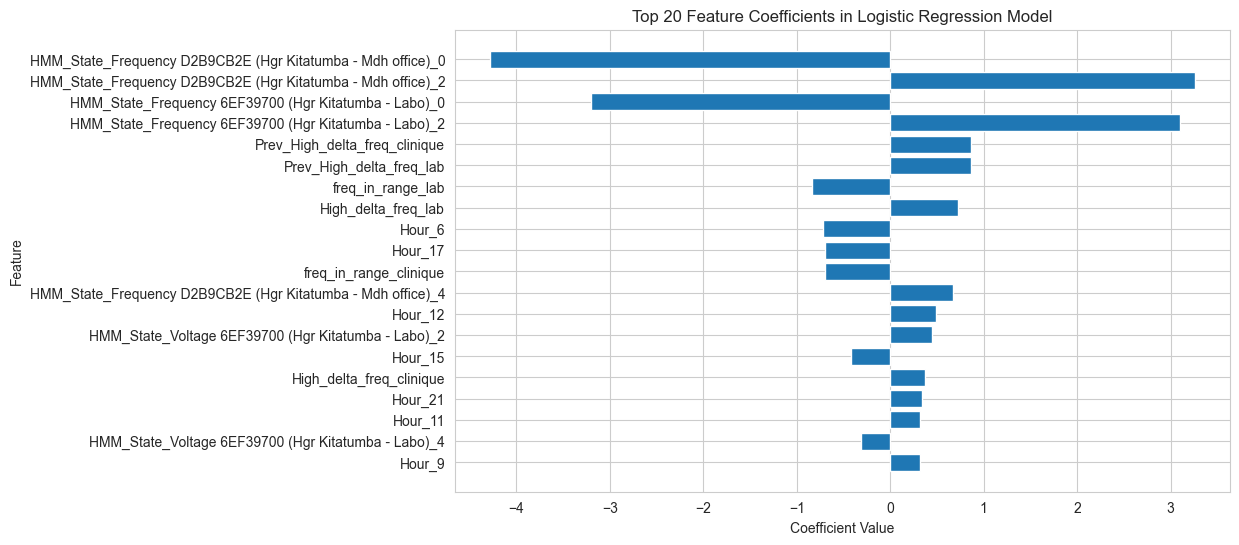

In [91]:
# Step 1: Create copies of the original data
train_data_ts_co_lg = train_data_ts_co.copy()
test_data_ts_co_lg = test_data_ts_co.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_co_lg, test_data_ts_co_lg = calculate_mean_flags(train_data_ts_co_lg, test_data_ts_co_lg, train_data_base,
                                                         columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

feature_columns = feature_columns + hmm_features

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_lg[feature_columns]
y_train = train_data_ts_co_lg['Generator_ON']

X_test = test_data_ts_co_lg[feature_columns]
y_test = test_data_ts_co_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_lg['prediction'] = clf.predict(X_train)
test_data_ts_co_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_co_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_co_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

In [92]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_lg['prediction'].value_counts())

# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_lg['prediction'].value_counts())

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_lg)
display_generator_statistics(test_data_ts_co_lg)

Train Set Evaluation:
Accuracy: 0.9995039682539683
Confusion Matrix:
[[10033     6]
 [    0  2057]]
Precision: 0.9970916141541445
Recall: 1.0
Train data prediction distribution:
prediction
False    10033
True      2063
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 0.9988839285714286
Confusion Matrix:
[[5969    7]
 [   2 2086]]
Precision: 0.9966555183946488
Recall: 0.9990421455938697
Test data prediction distribution:
prediction
False    5971
True     2093
Name: count, dtype: int64
##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2063 minutes, or 34.38 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2093 minutes, or 34.88 hours within 134.40 hours


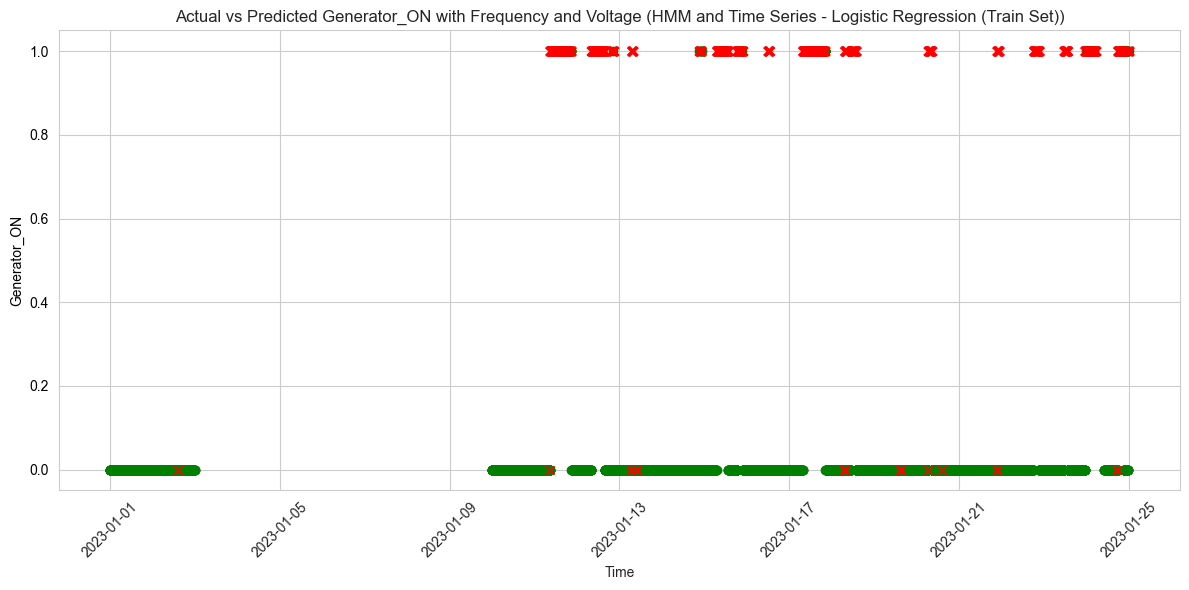

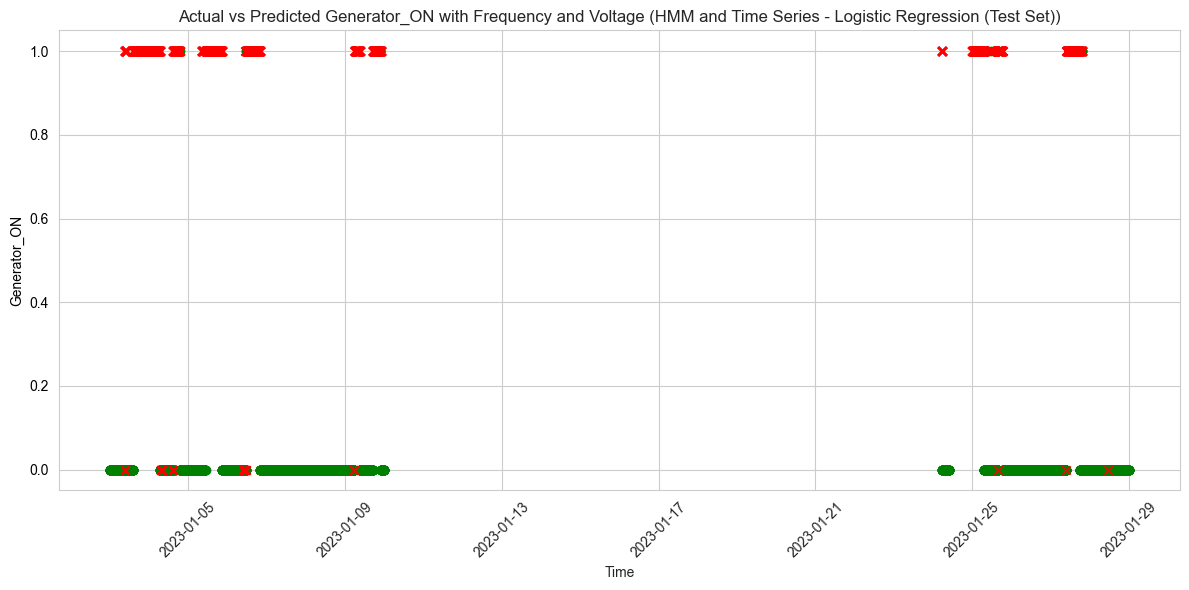

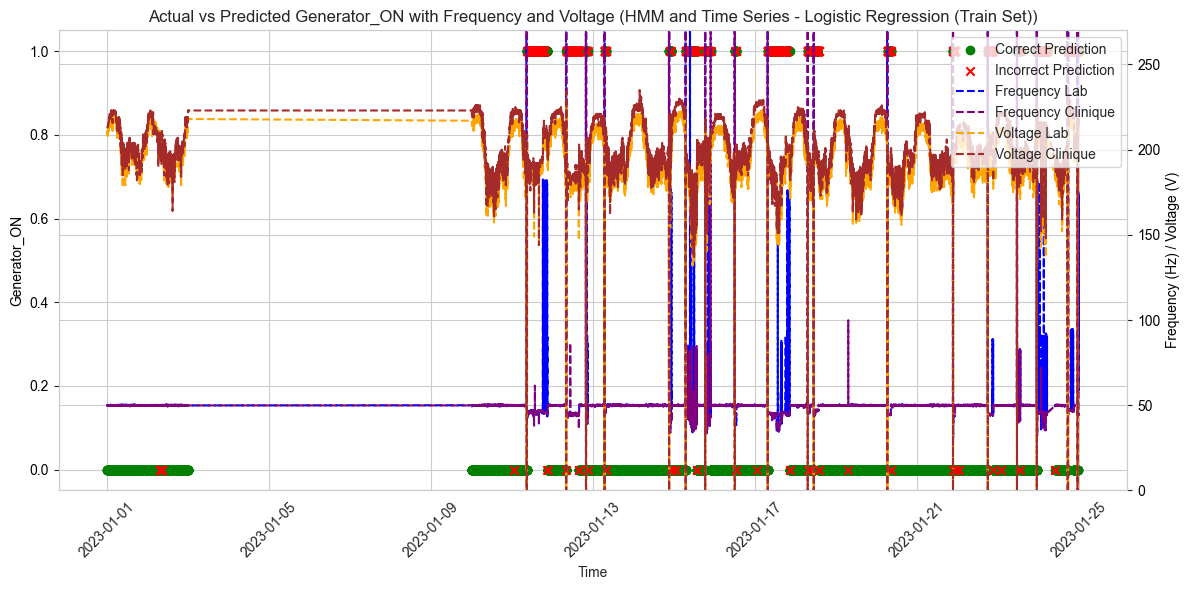

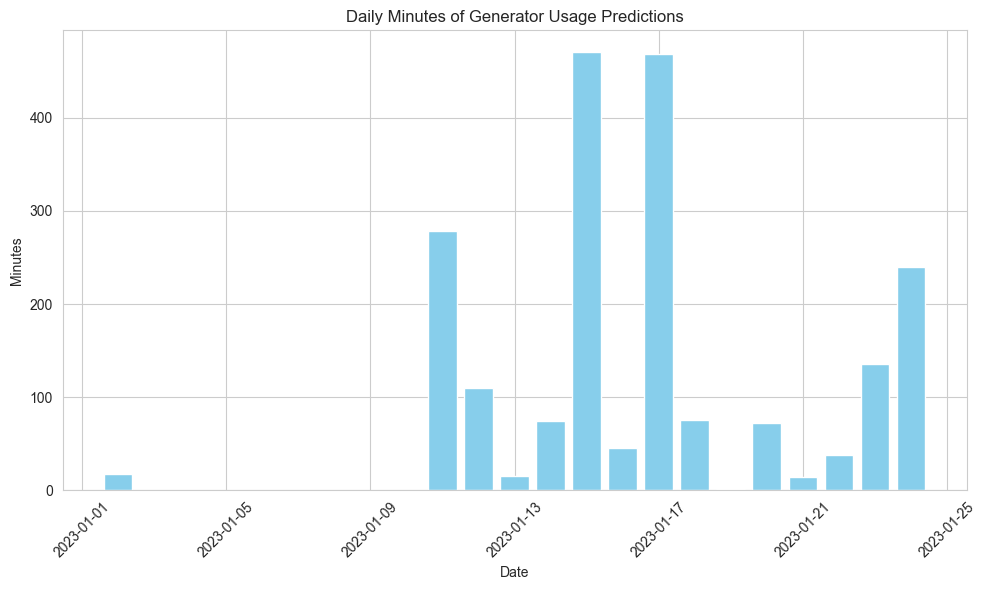

,Date,Count,Minutes,Hours
0,2023-01-02,9,18,0.300000
1,2023-01-11,139,278,4.633333
2,2023-01-12,55,110,1.833333
3,2023-01-13,8,16,0.266667
4,2023-01-14,37,74,1.233333
5,2023-01-15,235,470,7.833333
6,2023-01-16,23,46,0.766667
7,2023-01-17,234,468,7.800000
8,2023-01-18,38,76,1.266667
9,2023-01-19,1,2,0.033333


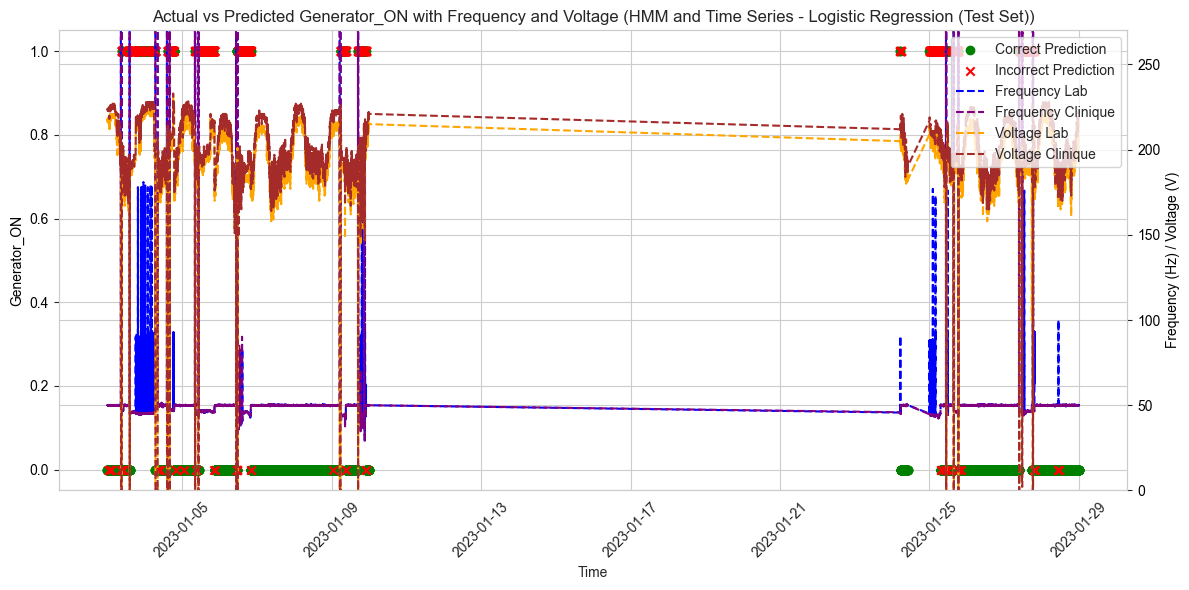

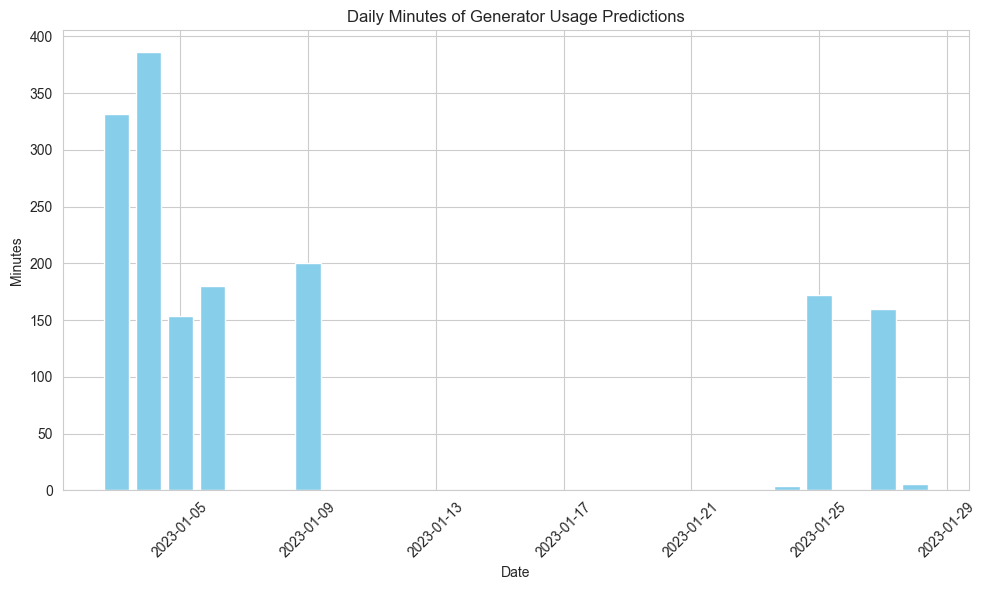

,Date,Count,Minutes,Hours
0,2023-01-03,166,332,5.533333
1,2023-01-04,193,386,6.433333
2,2023-01-05,77,154,2.566667
3,2023-01-06,90,180,3.000000
4,2023-01-09,100,200,3.333333
5,2023-01-24,2,4,0.066667
6,2023-01-25,86,172,2.866667
7,2023-01-27,80,160,2.666667
8,2023-01-28,3,6,0.100000


In [93]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False, include_frequency=False)

# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Train Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="HMM and Time Series - Logistic Regression (Test Set)",
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)


#### 4.3.2. Adding the Correlation functions (HMM)  - Random Forrest

Top 20 features sorted by importance:


,Feature,Importance
1,Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),0.238092
54,HMM_State_Frequency 6EF39700 (Hgr Kitatumba - ...,0.227450
57,HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - ...,0.200028
52,HMM_State_Frequency 6EF39700 (Hgr Kitatumba - ...,0.110575
0,Frequency 6EF39700 (Hgr Kitatumba - Labo),0.079299
59,HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - ...,0.059813
61,HMM_State_Frequency D2B9CB2E (Hgr Kitatumba - ...,0.022059
48,Prev_High_delta_freq_lab,0.008429
16,freq_in_range_lab,0.008105
8,Freq_delta_lab,0.006263


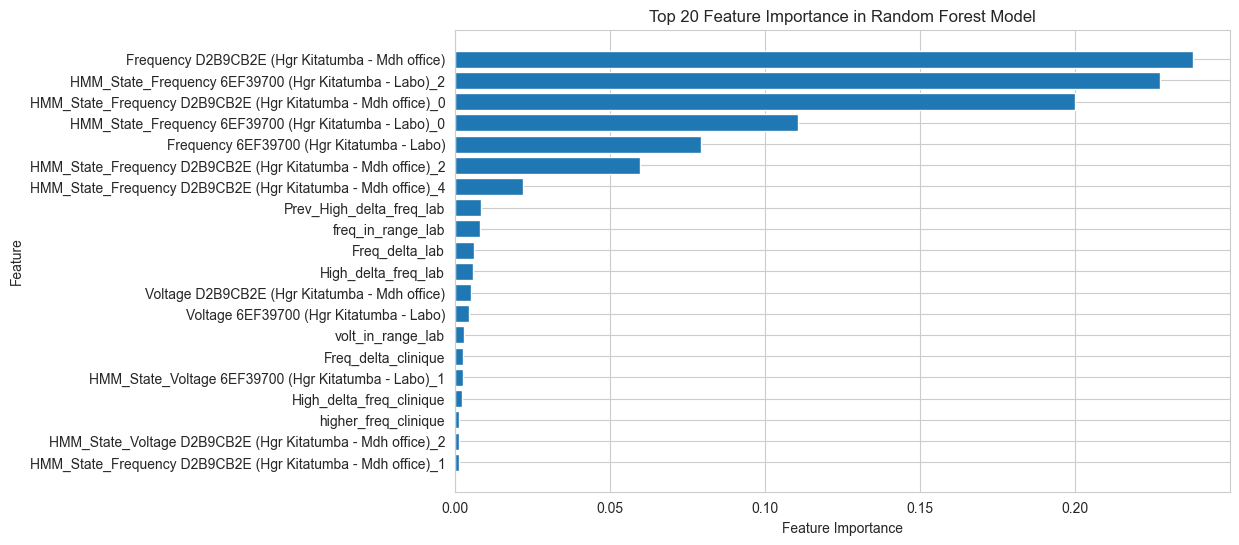

In [94]:
# Step 1: Create copies of the original data
train_data_ts_co_rf = train_data_ts_co.copy()
test_data_ts_co_rf = test_data_ts_co.copy()


# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_co_rf[feature_columns]
y_train = train_data_ts_co_rf['Generator_ON']

X_test = test_data_ts_co_rf[feature_columns]
y_test = test_data_ts_co_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_co_rf['prediction'] = clf.predict(X_train)
test_data_ts_co_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 15 most important features
print("Top 20 features sorted by importance:")
display(top_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

Evaluating the train and test set

Train Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution:
prediction
False    10039
True      2057
Name: count, dtype: int64
Test Set Evaluation:
Accuracy: 1.0
Confusion Matrix:
[[5976    0]
 [   0 2088]]
Precision: 1.0
Recall: 1.0
Test data prediction distribution:
prediction
False    5976
True     2088
Name: count, dtype: int64


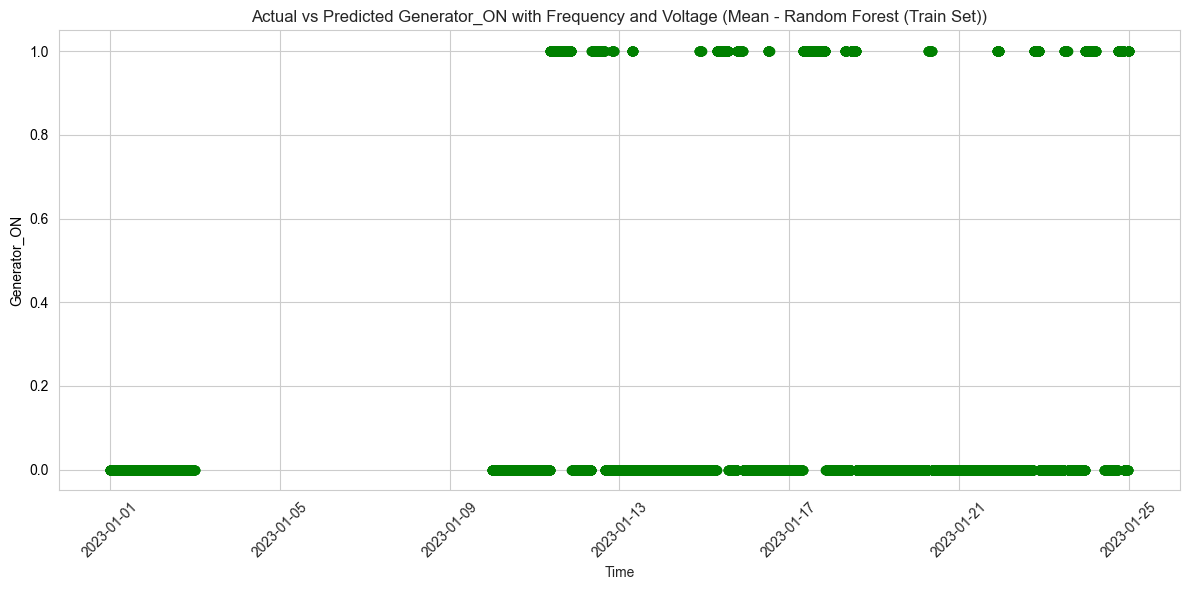

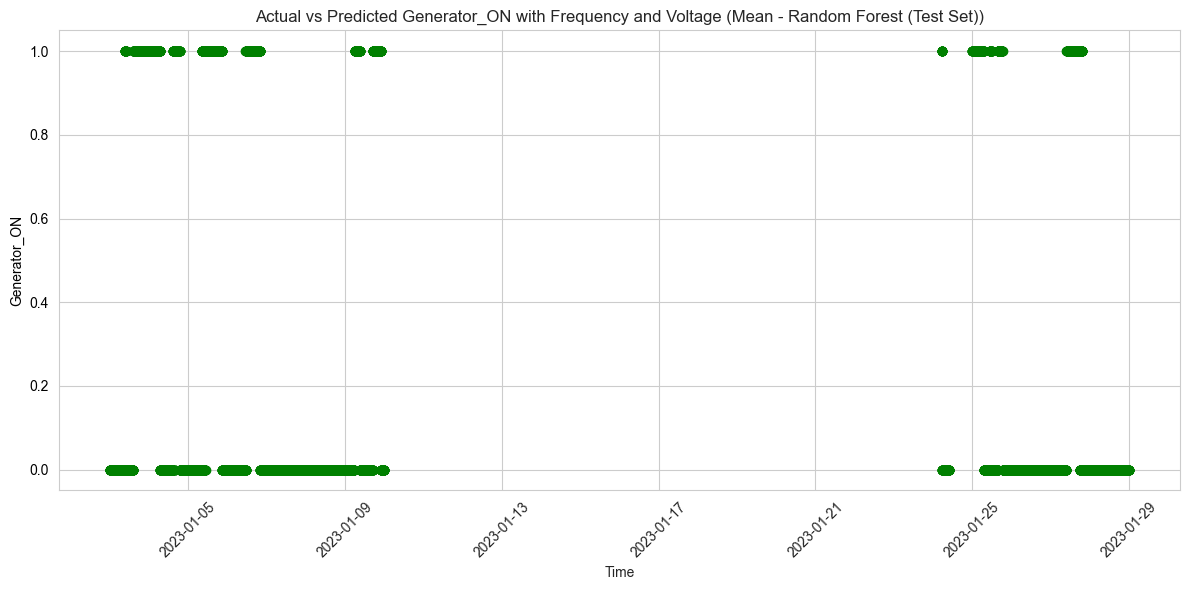

In [95]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_co_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_co_rf['prediction'].value_counts())
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_co_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_co_rf['prediction'].value_counts())

# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=False,
                            include_frequency=False)

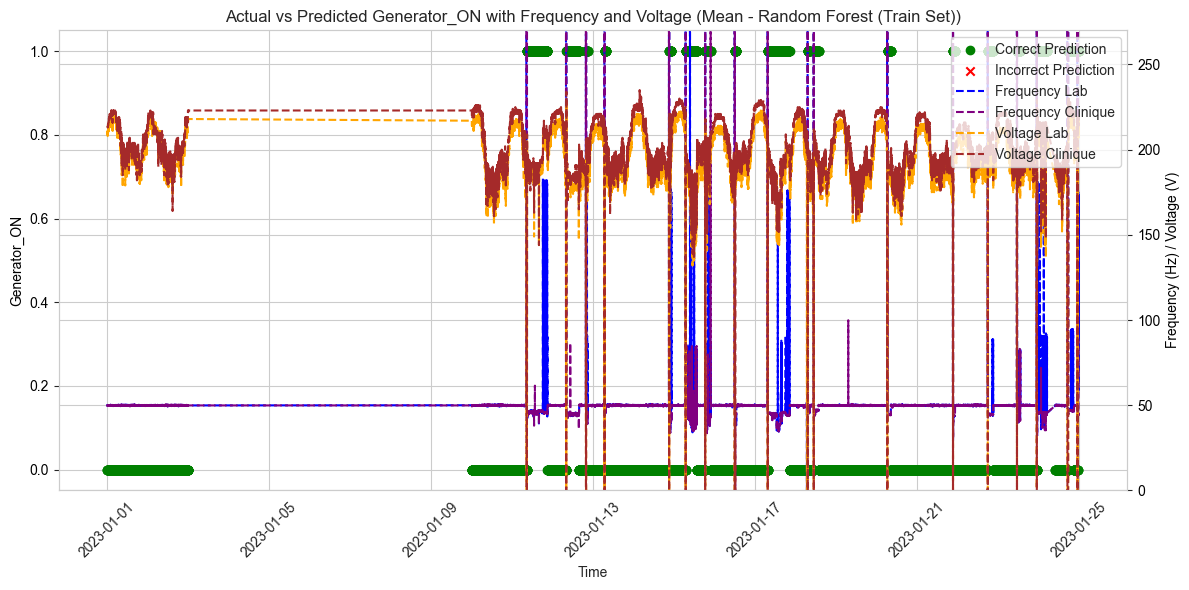

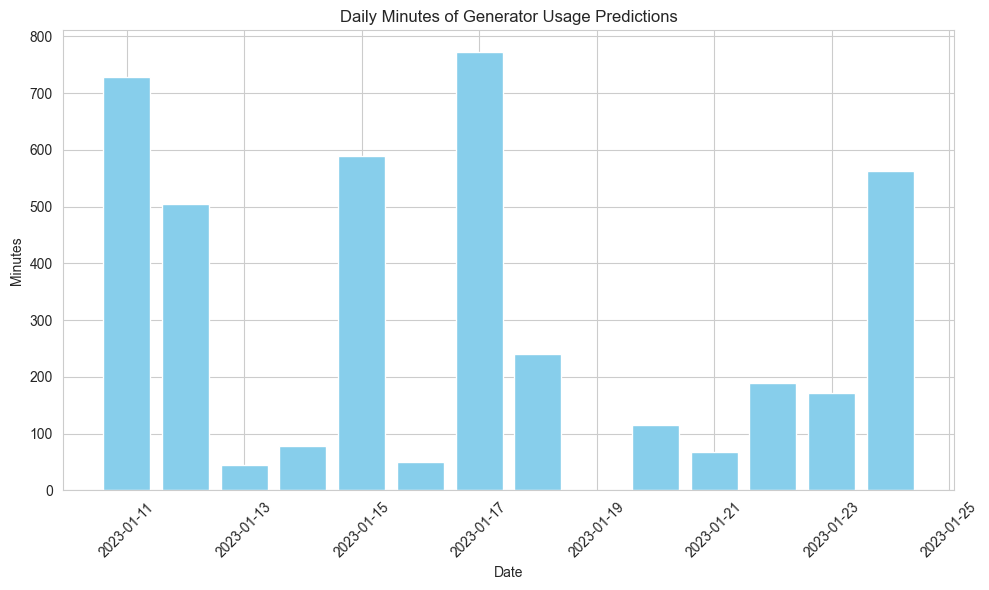

,Date,Count,Minutes,Hours
0,2023-01-11,364,728,12.133333
1,2023-01-12,252,504,8.400000
2,2023-01-13,22,44,0.733333
3,2023-01-14,39,78,1.300000
4,2023-01-15,295,590,9.833333
5,2023-01-16,25,50,0.833333
6,2023-01-17,386,772,12.866667
7,2023-01-18,120,240,4.000000
8,2023-01-20,58,116,1.933333
9,2023-01-21,34,68,1.133333


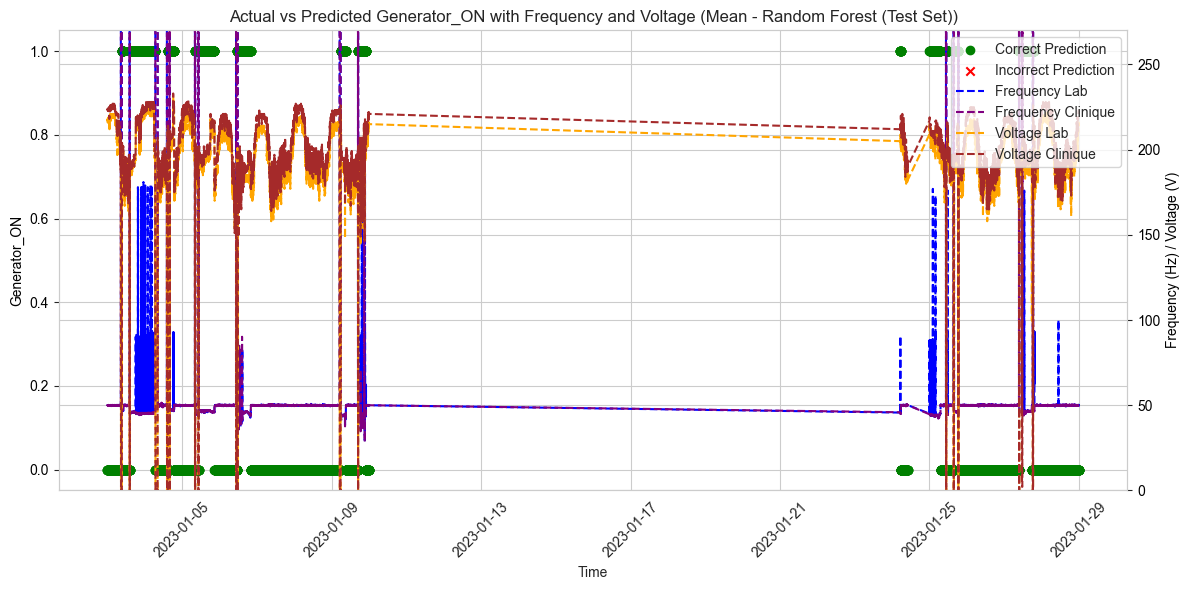

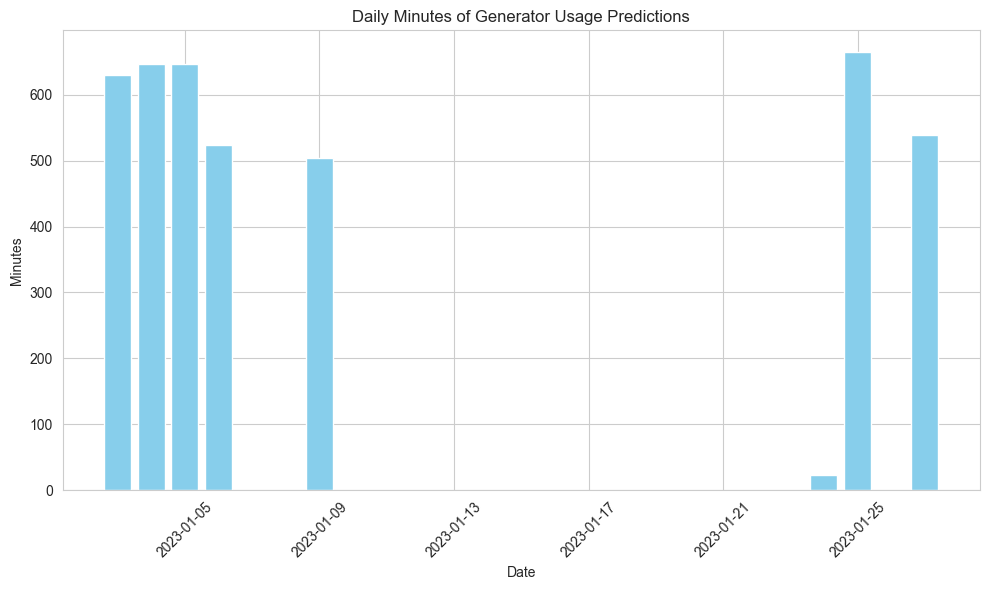

,Date,Count,Minutes,Hours
0,2023-01-03,315,630,10.500000
1,2023-01-04,323,646,10.766667
2,2023-01-05,323,646,10.766667
3,2023-01-06,262,524,8.733333
4,2023-01-09,252,504,8.400000
5,2023-01-24,12,24,0.400000
6,2023-01-25,332,664,11.066667
7,2023-01-27,269,538,8.966667


##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2088 minutes, or 34.80 hours within 134.40 hours


In [96]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_rf, model_name="Mean - Random Forest (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_rf_daily_count = plot_true_predictions_histogram(train_data_ts_co_rf)
display(train_data_ts_co_rf_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_rf, model_name="Mean - Random Forest (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_rf_daily_count = plot_true_predictions_histogram(test_data_ts_co_rf)
display(test_data_ts_co_rf_daily_count)
train_data_ts_co_rf['Generator_ON'].dtype

print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_rf)
display_generator_statistics(test_data_ts_co_rf)

#### 4.3.3. Adding the Correlation functions (HMM) - XGBoost

In [97]:
# Step 0: Copy rf data
train_data_ts_co_boost = train_data_ts_co.copy()
test_data_ts_co_boost = test_data_ts_co.copy()

# Step 1: Use the same data and feature columns (with copy to avoid SettingWithCopyWarning)
X_train = train_data_ts_co_boost[feature_columns].copy()
y_train = train_data_ts_co_boost['Generator_ON']

X_test = test_data_ts_co_boost[feature_columns].copy()
y_test = test_data_ts_co_boost['Generator_ON']

# Convert specific columns to numeric
cols_to_convert = [
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_train[cols_to_convert] = X_train[cols_to_convert].apply(pd.to_numeric, errors='coerce')
X_test[cols_to_convert] = X_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

#### This section is for XGBoost parameter search using cross validation

In [98]:
'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_co_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_co_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_co_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nf

In [99]:
# Use the best parameters from GridSearchCV - Saved so no need to re run the parameters. Only re run if we have additional features or different training data 

best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}


# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_co_boost['prediction'] = final_model.predict(X_train)
test_data_ts_co_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_co_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_co_boost['prediction']))

# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_co_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_co_boost['prediction'].value_counts())
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_co_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_co_boost['prediction'].value_counts())

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      5976
        True       1.00      1.00      1.00      2088

    accuracy                           1.00      8064
   macro avg       1.00      1.00      1.00      8064
weighted avg       1.00      1.00      1.00      8064

AUC-ROC Score:
1.0
Confusion Matrix:
[[5976    0]
 [   0 2088]]
Train Set Evaluation (XGBoost):
Accuracy: 1.0
Confusion Matrix:
[[10039     0]
 [    0  2057]]
Precision: 1.0
Recall: 1.0
Train data prediction distribution (XGBoost):
prediction
0    10039
1     2057
Name: count, dtype: int64

Test Set Evaluation (XGBoost):
Accuracy: 1.0
Confusion Matrix:
[[5976    0]
 [   0 2088]]
Precision: 1.0
Recall: 1.0
Test data prediction distribution (XGBoost):
prediction
0    5976
1    2088
Name: count, dtype: int64


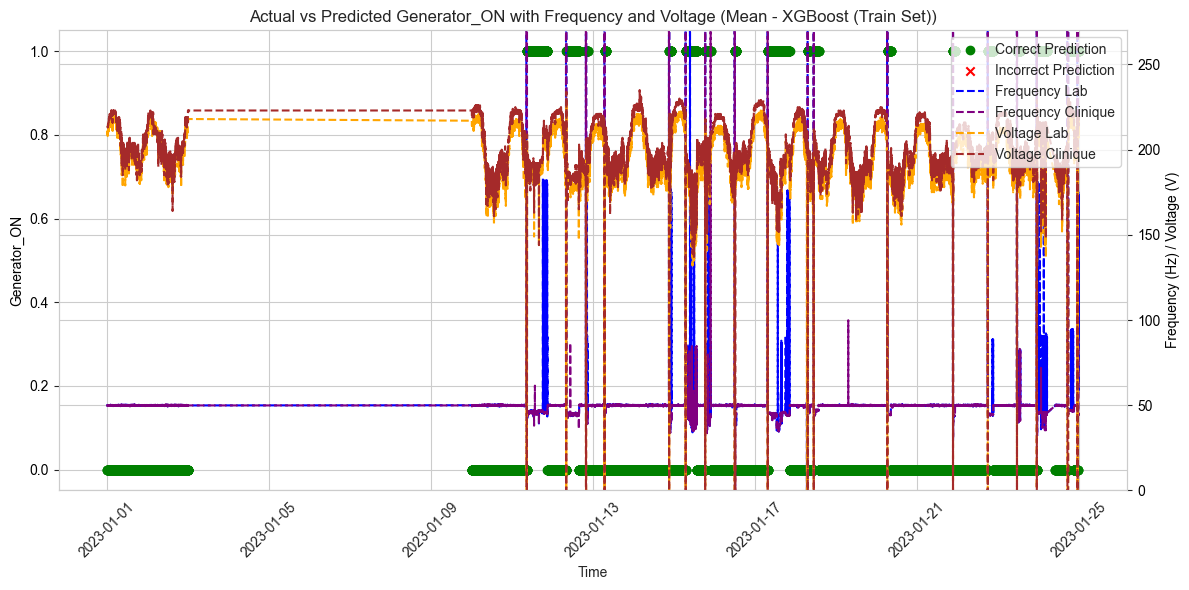

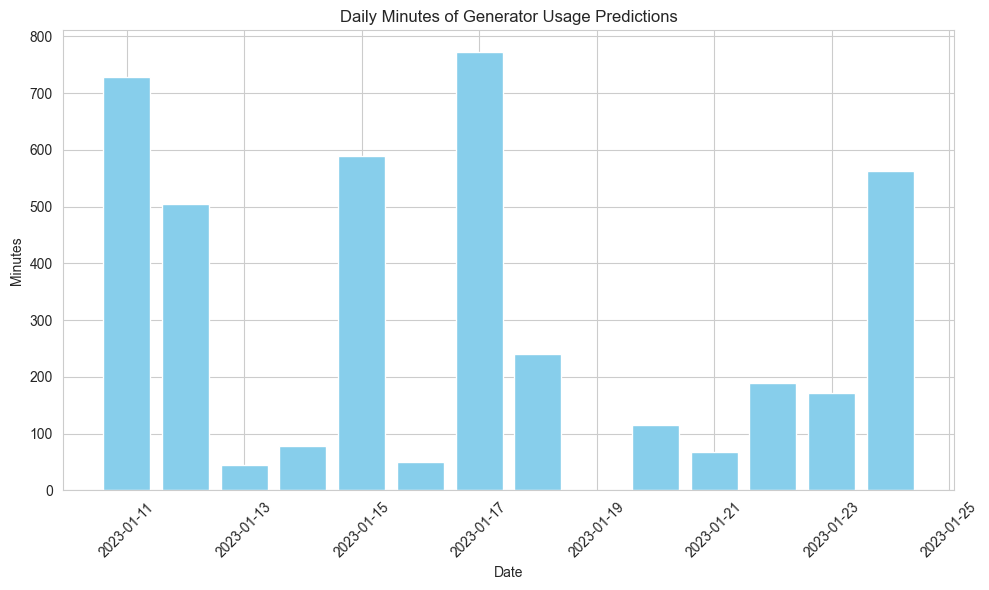

,Date,Count,Minutes,Hours
0,2023-01-11,364,728,12.133333
1,2023-01-12,252,504,8.400000
2,2023-01-13,22,44,0.733333
3,2023-01-14,39,78,1.300000
4,2023-01-15,295,590,9.833333
5,2023-01-16,25,50,0.833333
6,2023-01-17,386,772,12.866667
7,2023-01-18,120,240,4.000000
8,2023-01-20,58,116,1.933333
9,2023-01-21,34,68,1.133333


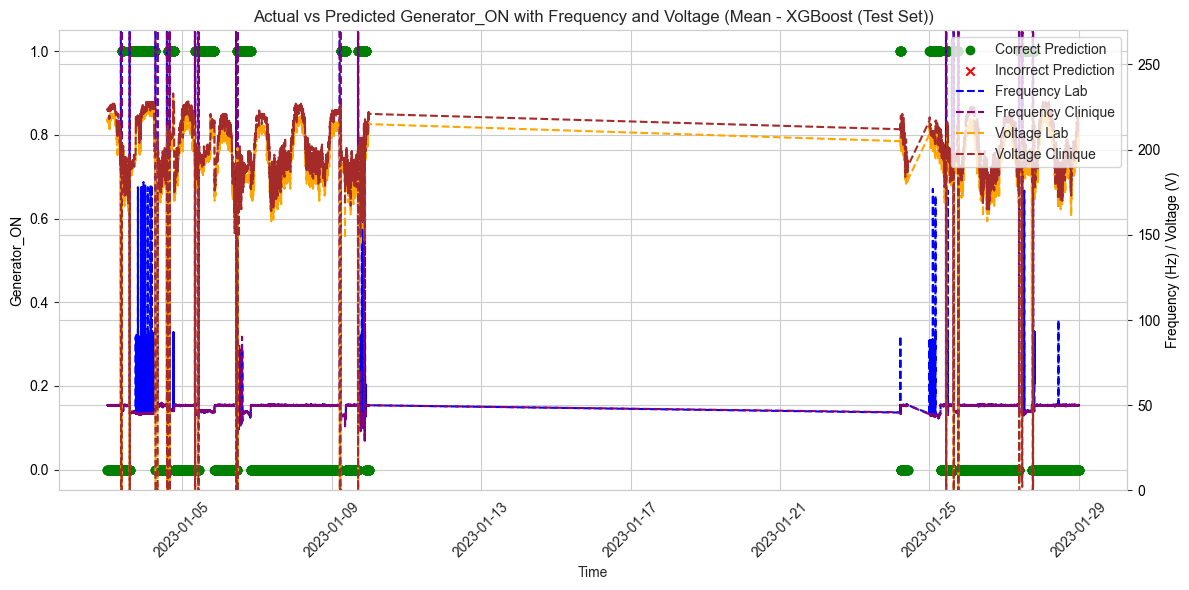

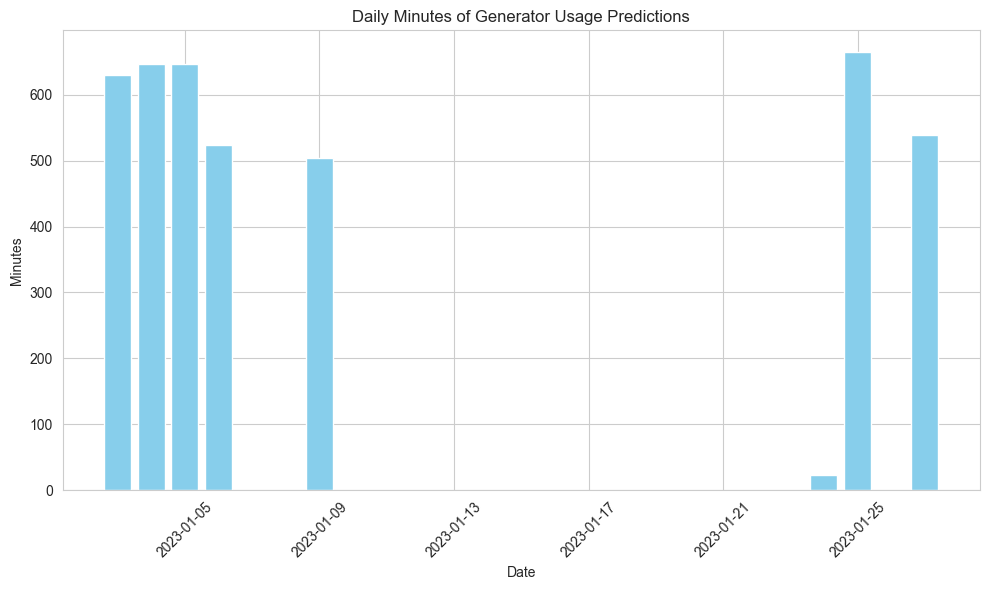

,Date,Count,Minutes,Hours
0,2023-01-03,315,630,10.500000
1,2023-01-04,323,646,10.766667
2,2023-01-05,323,646,10.766667
3,2023-01-06,262,524,8.733333
4,2023-01-09,252,504,8.400000
5,2023-01-24,12,24,0.400000
6,2023-01-25,332,664,11.066667
7,2023-01-27,269,538,8.966667


In [100]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_co_boost, model_name="Mean - XGBoost (Train Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
train_data_ts_co_boost_daily_count = plot_true_predictions_histogram(train_data_ts_co_boost)
display(train_data_ts_co_boost_daily_count)

# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_co_boost, model_name="Mean - XGBoost (Test Set)",   
                            freq_lab_column= freq_a,
                            freq_clinique_column= freq_b,
                            volt_lab_column= volt_a,
                            volt_clinique_column=volt_b,
                            include_voltage=True,
                            include_frequency=True)
test_data_ts_co_boost_daily_count = plot_true_predictions_histogram(test_data_ts_co_boost)
display(test_data_ts_co_boost_daily_count)

In [101]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_co_boost)
display_generator_statistics(test_data_ts_co_boost)

##### PREDICTION RESULT #####
Actual Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Predicted Minutes: 2057 minutes, or 34.28 hours within 201.60 hours
Actual Minutes: 2088 minutes, or 34.80 hours within 134.40 hours
Predicted Minutes: 2088 minutes, or 34.80 hours within 134.40 hours


## 5. Applying the Model with Other Data

Top 15 features sorted by importance:


,Feature,Importance
1,Frequency D2B9CB2E (Hgr Kitatumba - Mdh office),0.469519
0,Frequency 6EF39700 (Hgr Kitatumba - Labo),0.343138
48,Prev_High_delta_freq_lab,0.029578
44,High_delta_freq_lab,0.028621
8,Freq_delta_lab,0.021027
16,freq_in_range_lab,0.018172
9,Freq_delta_clinique,0.016080
3,Voltage D2B9CB2E (Hgr Kitatumba - Mdh office),0.010413
2,Voltage 6EF39700 (Hgr Kitatumba - Labo),0.009475
45,High_delta_freq_clinique,0.005058


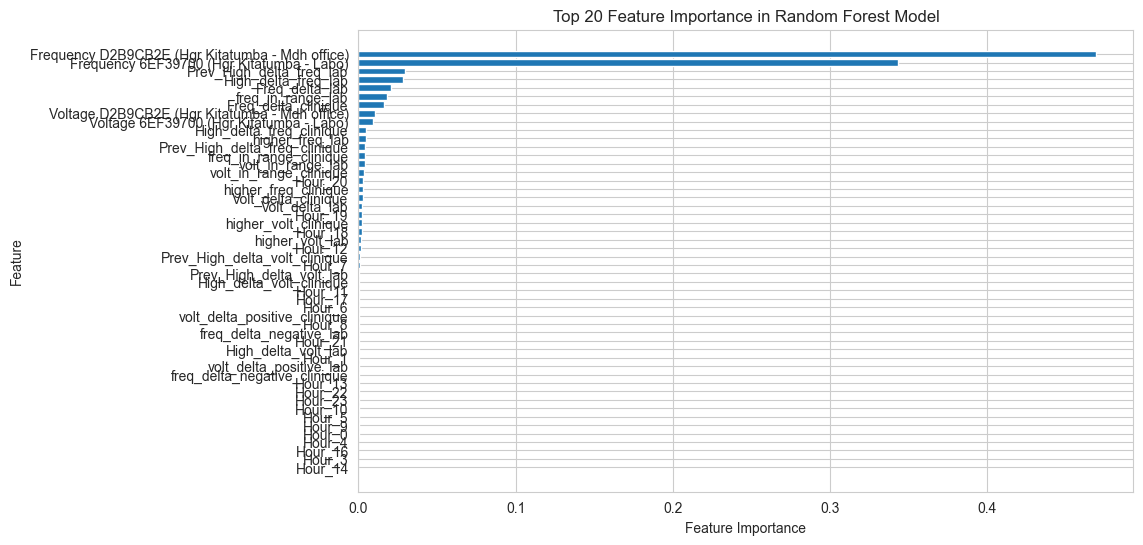

In [102]:
# Final Model use for prediction

# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [103]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = 'data/0. ChCbNdosho/New 2/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data/0. ChCbNdosho/New 2/Voltage Time Series-data-2024-10-25 13_13_06.csv'

In [ ]:
test_data_2

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [ ]:
# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.1. Plot Result During Lost Clinique Data (2023)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

##### 5.2.2. Plot Result First 10 days of July (2023)

In [ ]:
# Plot predictions based on certain timing choosen
start_date = '2023-02-14 00:00:00'
finished_date = '2023-02-17 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2022 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    freq_a, 
    freq_b, 
    volt_a, 
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

##### 5.2.2. Plot Result During Lost Clinique Data (2022)

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

#### 5.4. Using Data of Year 2024

In [ ]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/0. ChCbNdosho/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

In [ ]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, 
                                                        freq_lab_column= freq_a,
                                                        freq_clinique_column= freq_b,
                                                        volt_lab_column= volt_a,
                                                        volt_clinique_column= volt_b,
                                                        high_freq_threshold = high_freq_threshold,
                                                        low_freq_threshold = low_freq_threshold, 
                                                        high_volt_threshold = high_volt_threshold, 
                                                        low_volt_threshold = low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    freq_a,
    freq_b,
    volt_a,
    volt_b,
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

In [ ]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

In [ ]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

In [ ]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.2. Generator 2023 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 6.3. Generator 2024 Data

In [ ]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 7. Generator Power Calculation

In [ ]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

In [ ]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.2. Generator 2023 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

In [ ]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

#### 7.3. Generator 2024 Power

In [ ]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

In [ ]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

## 8. Generator Emission Calculation

In [ ]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [ ]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

In [ ]:
generator_emission_summary(test_data_2022)

#### 8.2. Generator 2023 Emission

In [ ]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

In [ ]:
generator_emission_summary(test_data_2023)

#### 8.3. Generator 2024 Emission

In [ ]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

In [ ]:
generator_emission_summary(test_data_2024)

## 9. Generator Output Emissions File

In [ ]:
file_name = ["data_2022.csv", "data_2023.csv", "data_2024.csv"]
years = [2022, 2023, 2024]
columns = ['Time','prediction','power (kW)','NOx Emission (g)','CO Emission (g)','SOx Emission (g)','CO2 Emission (g)','PM Emission (g)', 'Date', 'Month']

test_data_2024[columns].to_csv('results/data_2024.csv', index = False)
test_data_2023[columns].to_csv('results/data_2023.csv', index = False)
test_data_2022[columns].to_csv('results/data_2022.csv', index = False)